# Notebook 06b2 — Multi-Pathway NEB on All 171 ACAT Sites
## Hastelloy N | H₂ Dissociation Barrier Landscape (High Resolution)

Combines NB06a multi-pathway approach with NB06b 171-site resolution.

**Inputs:**
- 171 ACAT sites from NB04b `surface_sites.json`
- All intact H₂* sites from NB05b `H2_site_coords.json` (IS pool)
- All 171 H* sites from NB06b (FS pool)
- True labels and surface graph from Project 2

**Pipeline:**
- Cell A: Enumerate FS pairs from all 171 H* sites (H-H > 2.5 Å AND graph_dist ≥ 2)
- Cell B: All IS×FS combinations
- Cell C: Proximity filter (IS-FS centroid < 5 Å)
- Cell D: Write NEB scripts + SLURM array
- Cell E: Parse barriers, build matrix
- Cell F: Heatmap + MEP overlay (top 10 highlighted)

**Requires:** NB04b, NB05b, NB06b cells 3.2-3.3 completed

### Cell 0 — Setup

All system paths, NB05b/NB06b results, surface graph for graph distance.

In [2]:
import numpy as np
import os
import json
import subprocess
import shutil
import matplotlib.pyplot as plt
from ase.io import read
from collections import Counter
from itertools import combinations as iter_combinations
import warnings
warnings.filterwarnings('ignore')

import ase
print(f'ASE version : {ase.__version__}')
print(f'NumPy       : {np.__version__}')

# ═══════════════════════════════════════════════════════════
# SEED — change this to switch between seeds
# ═══════════════════════════════════════════════════════════
SEED = 7

# ═══════════════════════════════════════════════════════════
# SYSTEM PATHS
# ═══════════════════════════════════════════════════════════
LAMMPS_CMD        = '/projects/westgroup/akinyemi.az/mace_lammps/lammps/build-mliap/lmp'
MACE_MODEL_LAMMPS = '/projects/westgroup/akinyemi.az/mace_lammps/models/mace-mp-0b2-medium.model-mliap_lammps.pt'
MACE_MODEL_ASE    = '/projects/westgroup/akinyemi.az/mace_lammps/models/mace-mp-0b2-medium.model'
MACE_MODEL        = MACE_MODEL_LAMMPS
KOKKOS_FLAGS      = ['-k', 'on', 'g', '1', '-sf', 'kk',
                     '-pk', 'kokkos', 'newton', 'on', 'neigh', 'half']
SLURM_CONFIG = {
    'partition'     : 'multigpu',
    'ntasks'        : 1,
    'cpus_per_task' : 8,
    'gpu'           : 'a100:1',
    'time'          : '06:00:00',
    'conda_env'     : 'mace-lammps',
    'cuda_version'  : '12.3.0',
    'openmpi_ver'   : '4.1.6',
    'ld_paths'      : [
        '/shared/EL9/explorer/cuda/12.3.0/lib64/stubs',
        '/projects/westgroup/akinyemi.az/mace_lammps/lammps/build-mliap',
        '/home/akinyemi.az/miniforge3/envs/mace-lammps/lib',
    ]
}

# ── Atom type mapping ────────────────────────────────────────
ELEM_STR    = 'Al B C Cr Fe Mo Ni H'
PAIR_STYLE  = 'mliap unified'
PAIR_SUFFIX = '0'
E2T = {'Al':1, 'B':2, 'C':3, 'Cr':4, 'Fe':5, 'Mo':6, 'Ni':7, 'H':8}
MASSES = {
    1:(26.9815,'Al'), 2:(10.8110,'B'),  3:(12.0110,'C'),
    4:(51.9961,'Cr'), 5:(55.8450,'Fe'), 6:(95.9600,'Mo'),
    7:(58.6934,'Ni'), 8:( 1.0080,'H'),
}

# ── NEB parameters ───────────────────────────────────────────
N_REPLICAS   = 18
SPRING_CONST = 2.0
NEB_FTOL     = 0.05
N1_STEPS     = 5000
NEB_STEPS    = 10000

# ── Geometry constants ───────────────────────────────────────
Z_FREEZE_CUTOFF = 22.115
H_ATOM_HEIGHT   = 1.5
NN_CUTOFF       = 3.2

# ── Minimization settings ────────────────────────────────────
ETOL    = 0
FTOL    = 1e-6
MAXITER = 10000
MAXEVAL = 100000

# ── File paths (NB06b2 output dirs) ──────────────────────────
SLAB_RELAXED = f'structures/notebook05-adsorption-energy/{SEED}/clean_slab_reminimized.lammps'

for d in [
    f'structures/notebook06b2-Neb-dissociation/{SEED}/multi',
    f'results/notebook06b2-Neb-dissociation/{SEED}/multi',
    f'lammps_scripts/notebook06b2-Neb-dissociation/{SEED}/multi',
    f'slurm_scripts/notebook06b2-Neb-dissociation/{SEED}/multi',
]:
    os.makedirs(d, exist_ok=True)

# ── Helper: parse energy log ─────────────────────────────────
def parse_energy_log(logfile):
    results = {}
    if not os.path.exists(logfile):
        return None
    with open(logfile) as f:
        for line in f:
            line = line.strip()
            for key in ['pe_final_eV', 'fmax_eV_per_Ang', 'natoms']:
                if key in line and ':' in line:
                    try:
                        results[key] = float(line.split(':')[1].strip())
                    except:
                        pass
    return results if results else None

# ═══════════════════════════════════════════════════════════
# READ NB05b H2 RESULTS
# ═══════════════════════════════════════════════════════════
print(f'\nReading NB05b and NB06b results for SEED = {SEED}...\n')

# E_clean_slab and E_H2_gas from NB05b
res = parse_energy_log(f'results/notebook05b-adsorption-energy/{SEED}/ads_clean_slab.log')
if res is None:
    raise FileNotFoundError(f'NB05b clean_slab log not found for seed {SEED}')
E_CLEAN_SLAB = res['pe_final_eV']
print(f'E_clean_slab : {E_CLEAN_SLAB:.6f} eV')

res = parse_energy_log(f'results/notebook05b-adsorption-energy/{SEED}/ads_h2_gas.log')
if res is None:
    raise FileNotFoundError(f'NB05b h2_gas log not found for seed {SEED}')
E_H2_GAS = res['pe_final_eV']
print(f'E_H2_gas     : {E_H2_GAS:.6f} eV')

# ═══════════════════════════════════════════════════════════
# LOAD ACAT SITES FROM NB04b
# ═══════════════════════════════════════════════════════════
SURFACE_SITES_JSON = f'results/notebook04b-surface-relaxation/{SEED}/surface_sites.json'
with open(SURFACE_SITES_JSON) as f:
    surface_data = json.load(f)

sites_list  = surface_data['sites']
SITE_IDS    = [s['site_id'] for s in sites_list]
SITE_LABELS = {s['site_id']: s['level1']['full_label'] for s in sites_list}

print(f'\nLoaded {len(SITE_IDS)} ACAT sites from surface_sites.json')

# ═══════════════════════════════════════════════════════════
# LOAD NB05b H2 SITE COORDS (IS POOL — intact only)
# ═══════════════════════════════════════════════════════════
H2_JSON = f'results/notebook05b-adsorption-energy/{SEED}/H2_site_coords.json'
with open(H2_JSON) as f:
    h2_data = json.load(f)

# Filter intact H2 sites only — these are valid IS candidates
H2_INTACT_SITES = {sid: info for sid, info in h2_data['sites'].items()
                   if info.get('status') == 'intact'}

print(f'\nNB05b intact H2 sites (IS pool) : {len(H2_INTACT_SITES)}')

# H2 site centroid coordinates (relaxed positions)
H2_SITE_COORDS = {}
H2_ENERGIES    = {}

for sid in H2_INTACT_SITES:
    rpath = f'structures/notebook05b-adsorption-energy/{SEED}/ads_{sid}_relaxed.lammps'
    if not os.path.exists(rpath):
        continue
    slab = read(rpath, format='lammps-data', style='atomic')
    syms = np.array(slab.get_chemical_symbols())
    hpos = slab.get_positions()[syms == 'H']
    if len(hpos) == 2:
        cx, cy = hpos.mean(axis=0)[:2]
        H2_SITE_COORDS[sid] = (cx, cy)

    log = f'results/notebook05b-adsorption-energy/{SEED}/ads_{sid}.log'
    res = parse_energy_log(log)
    if res:
        H2_ENERGIES[sid] = res['pe_final_eV']

print(f'IS coords loaded : {len(H2_SITE_COORDS)} sites')
print(f'IS energies      : {len(H2_ENERGIES)} sites')

# True labels for IS sites
H2_TRUE_LABELS = {sid: info['true_label']
                  for sid, info in h2_data['sites'].items()}

# ═══════════════════════════════════════════════════════════
# LOAD NB06b H* RESULTS (FS POOL — all 171)
# ═══════════════════════════════════════════════════════════
h_energies = {}
h_eads     = {}

for sid in SITE_IDS:
    log = f'results/notebook06b-Neb-dissociation/{SEED}/h_atom_{sid}.log'
    res = parse_energy_log(log)
    if res and 'pe_final_eV' in res:
        h_energies[sid] = res['pe_final_eV']
        h_eads[sid]     = h_energies[sid] - E_CLEAN_SLAB - 0.5 * E_H2_GAS

print(f'\nNB06b H* energies loaded : {len(h_eads)} / {len(SITE_IDS)} sites')
if len(h_eads) < len(SITE_IDS):
    missing = [s for s in SITE_IDS if s not in h_eads]
    print(f'  Missing: {missing[:10]}{"..." if len(missing)>10 else ""}')

# H* relaxed coordinates (from NB06b)
SITE_COORDS = {}
for sid in SITE_IDS:
    rpath = f'structures/notebook06b-Neb-dissociation/{SEED}/h_atom_{sid}_relaxed.lammps'
    if not os.path.exists(rpath):
        continue
    slab = read(rpath, format='lammps-data', style='atomic')
    syms = np.array(slab.get_chemical_symbols())
    hpos = slab.get_positions()[syms == 'H']
    if len(hpos) == 1:
        SITE_COORDS[sid] = (hpos[0][0], hpos[0][1])

print(f'NB06b H* relaxed coords  : {len(SITE_COORDS)} sites')

# Load NB06b true labels
H_SITE_COORDS_JSON = f'results/notebook06b-Neb-dissociation/{SEED}/H_site_coords.json'
H_TRUE_LABELS = {}
if os.path.exists(H_SITE_COORDS_JSON):
    with open(H_SITE_COORDS_JSON) as f:
        h_data = json.load(f)
    H_TRUE_LABELS = {sid: info['true_label']
                     for sid, info in h_data.get('sites', {}).items()}
    print(f'NB06b H* true labels     : {len(H_TRUE_LABELS)} sites')

# ═══════════════════════════════════════════════════════════
# LOAD SURFACE GRAPH FOR GRAPH DISTANCE CHECK
# ═══════════════════════════════════════════════════════════
import sys
sys.path.append('Project2_surface_labeling')
from models.surface_graph import build_surface_graph
import networkx as nx

SLAB_FOR_ACAT = f'structures/notebook05-adsorption-energy/{SEED}/clean_slab_reminimized.lammps'
print('\nBuilding surface graph for graph distance calculation...')
G_surf, _, _, _ = build_surface_graph(SLAB_FOR_ACAT, seed=SEED)
print(f'  Graph: {G_surf.number_of_nodes()} nodes, {G_surf.number_of_edges()} edges')

# Build site-only subgraph for shortest_path_length (once, reused)
SITE_SUBGRAPH = nx.Graph()
for u, v, d in G_surf.edges(data=True):
    if d['edge_type'] == 'site-site':
        SITE_SUBGRAPH.add_edge(u, v)

def site_id_to_node(sid):
    """Map s_3 -> graph node 's_3' (direct since surface_graph uses same convention)."""
    return sid if sid in G_surf.nodes else None

def graph_distance(sid1, sid2):
    """Return graph distance between two site_ids on the site-site subgraph."""
    n1 = site_id_to_node(sid1)
    n2 = site_id_to_node(sid2)
    if n1 is None or n2 is None:
        return -1
    try:
        return nx.shortest_path_length(SITE_SUBGRAPH, n1, n2)
    except (nx.NetworkXNoPath, nx.NodeNotFound):
        return -1

print('\nSetup complete.')


ASE version : 3.27.0
NumPy       : 2.4.3

Reading NB05b and NB06b results for SEED = 7...

E_clean_slab : -2390.925227 eV
E_H2_gas     : -6.790499 eV

Loaded 171 ACAT sites from surface_sites.json

NB05b intact H2 sites (IS pool) : 157
IS coords loaded : 157 sites
IS energies      : 157 sites

NB06b H* energies loaded : 170 / 171 sites
  Missing: ['s_33']
NB06b H* relaxed coords  : 170 sites
NB06b H* true labels     : 170 sites

Building surface graph for graph distance calculation...
Reading slab...
  360 atoms  cell=[12.448 12.936 52.36 ]
  Top layer: 30 atoms  comp={np.str_('Ni'): 22, np.str_('Fe'): 1, np.str_('Cr'): 1, np.str_('Mo'): 4, np.str_('C'): 1, np.str_('B'): 1}
Running ACAT...
  n_layers used for ACAT  : 3
  171 valid sites
  Atom nodes: 30  Atom-atom edges: 88
  Site nodes: 171  Site-atom: 367  Site-site: 1904
  Total nodes: 201  Total edges: 2359
  Graph: 201 nodes, 2359 edges

Setup complete.


### Cell A — Enumerate all valid FS pairs from 171 H* sites

All H*+H* pairs from the 171 ACAT sites with:
- 2.5 Å ≤ H-H separation ≤ 8.0 Å
- Graph distance ≥ 2 (FS sites do not share a surface atom)
- Both E_ads(H*) < 0

C(171, 2) = 14535 candidate pairs, most filtered out.

In [3]:
# ─────────────────────────────────────────────────────────────
# Cell A — Enumerate FS pairs (171 H* sites version)
# ─────────────────────────────────────────────────────────────
from itertools import combinations

FS_SEP_MIN     = 2.5
FS_SEP_MAX     = 8.0
GRAPH_DIST_MIN = 2

# Only sites with valid coords AND negative E_ads
sites_pool = [s for s in SITE_IDS
              if s in h_eads and h_eads[s] < 0 and s in SITE_COORDS]

n_pool   = len(sites_pool)
n_pairs  = n_pool * (n_pool - 1) // 2
print(f'FS pool size : {n_pool} sites')
print(f'Candidate pairs: {n_pairs}')
print()

fs_pairs = []
n_check  = 0

print('Filtering pairs (this may take a moment)...')
for s1, s2 in combinations(sites_pool, 2):
    n_check += 1
    x1, y1 = SITE_COORDS[s1]
    x2, y2 = SITE_COORDS[s2]
    sep = np.sqrt((x1-x2)**2 + (y1-y2)**2)

    if sep < FS_SEP_MIN or sep > FS_SEP_MAX:
        continue

    gdist = graph_distance(s1, s2)
    if gdist >= 0 and gdist < GRAPH_DIST_MIN:
        continue

    combined = h_eads[s1] + h_eads[s2]
    fs_pairs.append({
        'site1'        : s1,
        'site2'        : s2,
        'sep'          : sep,
        'graph_dist'   : gdist,
        'combined_eads': combined,
        'E_FS'         : h_energies[s1] + h_energies[s2] - E_CLEAN_SLAB,
        'label'        : f'{s1}+{s2}',
        'true_label1'  : H_TRUE_LABELS.get(s1, s1),
        'true_label2'  : H_TRUE_LABELS.get(s2, s2),
    })

# Sort by combined stability — most stable FS first
fs_pairs = sorted(fs_pairs, key=lambda x: x['combined_eads'])

print(f'Checked  : {n_check} pairs')
print(f'Passed   : {len(fs_pairs)} pairs')
print()
print('Top 20 FS pairs by combined stability:')
print(f'  {"#":>3s}  {"site1":8s} {"site2":8s}  {"sep":>6s}  {"gdist":>5s}  '
      f'{"E1+E2":>10s}  {"true_label1":28s} {"true_label2"}')
print('  ' + '-' * 100)
for i, p in enumerate(fs_pairs[:20], 1):
    print(f'  {i:3d}  {p["site1"]:8s} {p["site2"]:8s}  '
          f'{p["sep"]:6.3f}  {p["graph_dist"]:>5d}  {p["combined_eads"]:10.4f}  '
          f'{p["true_label1"]:28s} {p["true_label2"]}')


FS pool size : 170 sites
Candidate pairs: 14365

Filtering pairs (this may take a moment)...
Checked  : 14365 pairs
Passed   : 7618 pairs

Top 20 FS pairs by combined stability:
    #  site1    site2        sep  gdist       E1+E2  true_label1                  true_label2
  ----------------------------------------------------------------------------------------------------
    1  s_118    s_127      2.586      2     -1.6857  MoMoNi_hollow_hcp            MoMoNi_hollow_hcp
    2  s_118    s_135      2.586      3     -1.6857  MoMoNi_hollow_hcp            MoMoNi_hollow_hcp
    3  s_118    s_154      2.586      3     -1.6857  MoMoNi_hollow_hcp            MoMoNi_hollow_hcp
    4  s_119    s_135      2.586      2     -1.6857  MoMoNi_hollow_hcp            MoMoNi_hollow_hcp
    5  s_119    s_154      2.586      2     -1.6857  MoMoNi_hollow_hcp            MoMoNi_hollow_hcp
    6  s_120    s_135      2.586      2     -1.6857  MoMoNi_hollow_hcp            MoMoNi_hollow_hcp
    7  s_120    s_154    

In [4]:
# ─────────────────────────────────────────────────────────────
# Cell A+ — Deduplicate FS pairs by Level 1 + Level 2 elements
# ─────────────────────────────────────────────────────────────
import json

# Load surface_sites.json (skip if already loaded in earlier cell)
with open(f'results/notebook04b-surface-relaxation/{SEED}/surface_sites.json') as f:
    surface_data = json.load(f)
sites_dict = {s['site_id']: s for s in surface_data['sites']}


def site_signature(site_id):
    """
    Build a signature for a site based on its constituent atoms (Level 1)
    and the direct neighbors of those atoms (Level 2 shell 1).
    Element types only — distances and indices are ignored.
    """
    site = sites_dict[site_id]

    # Level 1: sorted multiset of constituent atom elements
    l1_elements = tuple(sorted(
        atom['element'] for atom in site['level1']['constituent_atoms']
    ))

    # Level 2: for each Level 1 atom, the sorted multiset of shell 1 elements
    l2_envs = []
    for atom_idx_str, env in site['level2'].items():
        atom_element = env['element']
        shell1_elements = tuple(sorted(
            n['element'] for n in env.get('shell1', [])
        ))
        l2_envs.append((atom_element, shell1_elements))
    # Sort the Level 2 envs so the signature is order-independent
    l2_envs = tuple(sorted(l2_envs))

    return (l1_elements, l2_envs)


def pair_signature(s1, s2):
    """Order-independent signature for a pair of sites."""
    sig1 = site_signature(s1)
    sig2 = site_signature(s2)
    return tuple(sorted([sig1, sig2]))


# Group fs_pairs by signature (fs_pairs is already sorted by combined_eads)
groups = {}
for p in fs_pairs:
    psig = pair_signature(p['site1'], p['site2'])
    groups.setdefault(psig, []).append(p)

# Keep only the most stable (first) representative from each group
unique_pairs = [g[0] for g in groups.values()]
unique_pairs = sorted(unique_pairs, key=lambda x: x['combined_eads'])

# Annotate each unique pair with how many duplicates it represents
for p in unique_pairs:
    p['n_grouped'] = len(groups[pair_signature(p['site1'], p['site2'])])

print(f'Original FS pairs       : {len(fs_pairs)}')
print(f'Unique chemistry pairs  : {len(unique_pairs)}')
print(f'Compression ratio       : {len(fs_pairs) / len(unique_pairs):.1f}x')
print()

group_sizes = sorted([len(g) for g in groups.values()], reverse=True)
print(f'Largest group           : {group_sizes[0]} pairs collapsed to 1')
print(f'Smallest group          : {group_sizes[-1]} pair(s)')
print(f'Mean group size         : {sum(group_sizes)/len(group_sizes):.1f}')
print()

print(f'Top 30 unique FS pairs by combined stability:')
print(f'  {"#":>3s}  {"site1":8s} {"site2":8s}  {"sep":>6s}  {"gdist":>5s}  '
      f'{"E1+E2":>10s}  {"true_label1":28s} {"true_label2":28s} {"n_grp":>5s}')
print('  ' + '-' * 120)
for i, p in enumerate(unique_pairs[:30], 1):
    print(f'  {i:3d}  {p["site1"]:8s} {p["site2"]:8s}  '
          f'{p["sep"]:6.3f}  {p["graph_dist"]:>5d}  {p["combined_eads"]:10.4f}  '
          f'{p["true_label1"]:28s} {p["true_label2"]:28s} {p["n_grouped"]:>5d}')

Original FS pairs       : 7618
Unique chemistry pairs  : 5221
Compression ratio       : 1.5x

Largest group           : 11 pairs collapsed to 1
Smallest group          : 1 pair(s)
Mean group size         : 1.5

Top 30 unique FS pairs by combined stability:
    #  site1    site2        sep  gdist       E1+E2  true_label1                  true_label2                  n_grp
  ------------------------------------------------------------------------------------------------------------------------
    1  s_118    s_127      2.586      2     -1.6857  MoMoNi_hollow_hcp            MoMoNi_hollow_hcp                4
    2  s_118    s_135      2.586      3     -1.6857  MoMoNi_hollow_hcp            MoMoNi_hollow_hcp                3
    3  s_118    s_154      2.586      3     -1.6857  MoMoNi_hollow_hcp            MoMoNi_hollow_hcp                2
    4  s_119    s_135      2.586      2     -1.6857  MoMoNi_hollow_hcp            MoMoNi_hollow_hcp                2
    5  s_119    s_154      2.586   

### Cell B — Enumerate all IS→FS combinations

`N_intact_H2 × N_FS_pairs` combinations total.

In [5]:
# ─────────────────────────────────────────────────────────────
# Cell B — Enumerate IS × FS combinations
# ─────────────────────────────────────────────────────────────
fs_pairs = unique_pairs
# Only IS sites that have a relaxed structure AND a logged energy
is_sites_valid = [sid for sid in H2_INTACT_SITES
                  if sid in H2_SITE_COORDS and sid in H2_ENERGIES]
print(f'Valid IS sites : {len(is_sites_valid)}')
print(f'Valid FS pairs : {len(fs_pairs)}')

all_combinations = []

for is_site in is_sites_valid:
    ix, iy = H2_SITE_COORDS[is_site]
    E_IS   = H2_ENERGIES[is_site]
    is_label = H2_TRUE_LABELS.get(is_site, is_site)

    for fp in fs_pairs:
        s1, s2   = fp['site1'], fp['site2']
        fx1, fy1 = SITE_COORDS[s1]
        fx2, fy2 = SITE_COORDS[s2]
        fcx      = (fx1 + fx2) / 2
        fcy      = (fy1 + fy2) / 2

        is_fs_dist = np.sqrt((ix - fcx)**2 + (iy - fcy)**2)
        E_FS    = h_energies[s1] + h_energies[s2] - E_CLEAN_SLAB
        dE      = E_FS - E_IS
        label   = f'{is_site}__{s1}+{s2}'

        all_combinations.append({
            'is_site'      : is_site,
            'is_true_label': is_label,
            'fs_site1'     : s1,
            'fs_site2'     : s2,
            'fs_true_label1': fp['true_label1'],
            'fs_true_label2': fp['true_label2'],
            'is_xy'         : (ix, iy),
            'fs_centroid'   : (fcx, fcy),
            'is_fs_dist'    : is_fs_dist,
            'E_IS'          : E_IS,
            'E_FS'          : E_FS,
            'delta_E'       : dE,
            'fs_sep'        : fp['sep'],
            'graph_dist'    : fp['graph_dist'],
            'label'         : label,
        })

all_combinations = sorted(all_combinations, key=lambda x: x['delta_E'])

print(f'\nTotal IS→FS combinations : {len(all_combinations)}')
print(f'\nTop 20 by delta_E (most exothermic):')
print(f'  {"#":>4s}  {"label":50s}  {"is-fs":>8s}  {"dE (eV)":>9s}')
print('  ' + '-' * 80)
for i, c in enumerate(all_combinations[:200], 1):
    print(f'  {i:4d}  {c["label"]:50s}  {c["is_fs_dist"]:8.4f}  {c["delta_E"]:9.4f}')


Valid IS sites : 157
Valid FS pairs : 5221

Total IS→FS combinations : 819697

Top 20 by delta_E (most exothermic):
     #  label                                                  is-fs    dE (eV)
  --------------------------------------------------------------------------------
     1  s_114__s_118+s_127                                    7.0766    -1.8758
     2  s_114__s_118+s_135                                    7.0766    -1.8758
     3  s_114__s_118+s_154                                    7.0766    -1.8758
     4  s_114__s_119+s_135                                    7.0766    -1.8758
     5  s_114__s_119+s_154                                    7.0766    -1.8758
     6  s_114__s_120+s_135                                    7.0766    -1.8758
     7  s_114__s_120+s_154                                    7.0766    -1.8758
     8  s_114__s_122+s_127                                    7.0766    -1.8758
     9  s_114__s_122+s_135                                    7.0766    -1.8758
 

### Cell C — Proximity filter

Keep only IS→FS pairs where IS H₂ centroid is within `PROX_CUTOFF` of the FS pair centroid. This drops physically implausible combinations where dissociation would require long-range rearrangement.

In [6]:
# ─────────────────────────────────────────────────────────────
# Cell C — Proximity filter (IS-FS centroid distance)
# ─────────────────────────────────────────────────────────────
PROX_CUTOFF = 5.0   # A

filtered_combinations = [c for c in all_combinations
                          if c['is_fs_dist'] < PROX_CUTOFF]

print(f'Proximity filter: IS-FS centroid distance < {PROX_CUTOFF} A')
print(f'  Before filter : {len(all_combinations)} combinations')
print(f'  After filter  : {len(filtered_combinations)} combinations')
print()
print(f'Combinations to run as NEB: {len(filtered_combinations)}')
print()

# Optional: cap to top N if too many
HARD_CAP = None   # set to integer (e.g. 200) to cap, or None for no cap
if HARD_CAP is not None and len(filtered_combinations) > HARD_CAP:
    print(f'WARNING: capping to top {HARD_CAP} by delta_E (most exothermic)')
    filtered_combinations = filtered_combinations[:HARD_CAP]
    print(f'  After cap     : {len(filtered_combinations)} combinations')

print()
print(f'Top 30:')
print(f'  {"#":>4s}  {"label":50s}  {"is-fs":>7s}  {"dE":>9s}  {"fs sep":>7s}  {"gdist":>5s}')
print('  ' + '-' * 100)
for i, c in enumerate(filtered_combinations[:30], 1):
    print(f'  {i:4d}  {c["label"]:50s}  '
          f'{c["is_fs_dist"]:7.4f}  {c["delta_E"]:9.4f}  '
          f'{c["fs_sep"]:7.4f}  {c["graph_dist"]:>5d}')


Proximity filter: IS-FS centroid distance < 5.0 A
  Before filter : 819697 combinations
  After filter  : 338830 combinations

Combinations to run as NEB: 338830


Top 30:
     #  label                                                 is-fs         dE   fs sep  gdist
  ----------------------------------------------------------------------------------------------------
     1  s_169__s_118+s_127                                   4.2826    -1.8656   2.5859      2
     2  s_169__s_118+s_135                                   4.2826    -1.8656   2.5859      3
     3  s_169__s_118+s_154                                   4.2826    -1.8656   2.5859      3
     4  s_169__s_119+s_135                                   4.2826    -1.8656   2.5859      2
     5  s_169__s_119+s_154                                   4.2826    -1.8656   2.5859      2
     6  s_169__s_120+s_135                                   4.2826    -1.8656   2.5859      2
     7  s_169__s_120+s_154                                  

### Cell D — Write all NEB scripts and SLURM array

For each filtered combination:
- IS structure copied from NB05b `ads_{is_site}_relaxed.lammps`
- FS structure built by placing 2 H atoms at fs_site1 and fs_site2 positions
- FS minimization LAMMPS script
- ASE NEB script (MDMin phase 1 + CINEB phase 2, IDPP interpolation)
- All submitted as one SLURM array `--array=0-{N-1}%8`

In [6]:
# # ─────────────────────────────────────────────────────────────
# # Cell D — Write all NEB scripts and submit as SLURM array
# # ─────────────────────────────────────────────────────────────
# sc = SLURM_CONFIG
# kk = ' '.join(KOKKOS_FLAGS)
# ld = '\n'.join(f'export LD_LIBRARY_PATH={p}:$LD_LIBRARY_PATH'
#                for p in sc['ld_paths'])
# cwd = os.getcwd()

# neb_jobs_written = []

# print(f'Writing NEB scripts for {len(filtered_combinations)} combinations...')

# for c in filtered_combinations:
#     label    = c['label']
#     is_site  = c['is_site']
#     fs_site1 = c['fs_site1']
#     fs_site2 = c['fs_site2']
#     E_IS     = c['E_IS']
#     true_is  = c['is_true_label']
#     true_fs1 = c['fs_true_label1']
#     true_fs2 = c['fs_true_label2']
#     gdist    = c['graph_dist']

#     # ── Directories ───────────────────────────────────────────
#     struct_dir = f'structures/notebook06b2-Neb-dissociation/{SEED}/multi/{label}'
#     result_dir = f'results/notebook06b2-Neb-dissociation/{SEED}/multi/{label}'
#     script_dir = f'lammps_scripts/notebook06b2-Neb-dissociation/{SEED}/multi/{label}'
#     for d in [struct_dir, result_dir, script_dir]:
#         os.makedirs(d, exist_ok=True)

#     # ── IS structure — copy from NB05b, strip Velocities ─────
#     is_src  = f'structures/notebook05b-adsorption-energy/{SEED}/ads_{is_site}_relaxed.lammps'
#     is_dest = f'{struct_dir}/neb_initial.lammps'
#     with open(is_src) as f:
#         content = f.read()
#     if 'Velocities' in content:
#         content = content[:content.index('Velocities')].rstrip() + '\n'
#     with open(is_dest, 'w') as f:
#         f.write(content)

#     # ── FS structure — place 2 H atoms at fs_site1 + fs_site2 ─
#     is_slab  = read(is_dest, format='lammps-data', style='atomic')
#     is_pos   = is_slab.get_positions()
#     is_syms  = np.array(is_slab.get_chemical_symbols())
#     cell     = is_slab.cell.diagonal()
#     z_surf_v = is_pos[is_syms != 'H', 2].max()
#     z_fs     = z_surf_v + H_ATOM_HEIGHT

#     x1, y1  = SITE_COORDS[fs_site1]
#     x2, y2  = SITE_COORDS[fs_site2]
#     h1_fs   = np.array([x1 % cell[0], y1 % cell[1], z_fs])
#     h2_fs   = np.array([x2 % cell[0], y2 % cell[1], z_fs])

#     metal_pos   = is_pos[is_syms != 'H']
#     metal_syms  = is_syms[is_syms != 'H']
#     fs_all_pos  = np.vstack([metal_pos, h1_fs, h2_fs])
#     fs_all_syms = np.concatenate([metal_syms, ['H', 'H']])

#     fs_raw_path = f'{struct_dir}/neb_final_raw.lammps'
#     with open(fs_raw_path, 'w') as f:
#         f.write(f'# NEB FS: 2H* at {fs_site1} + {fs_site2} - NB06b2\n\n')
#         f.write(f'{len(fs_all_pos)} atoms\n8 atom types\n\n')
#         f.write(f'0.0 {cell[0]:.10f} xlo xhi\n')
#         f.write(f'0.0 {cell[1]:.10f} ylo yhi\n')
#         f.write(f'0.0 {cell[2]:.10f} zlo zhi\n\n')
#         f.write('Masses\n\n')
#         for t, (m, el) in MASSES.items():
#             f.write(f'{t}  {m}  # {el}\n')
#         f.write('\nAtoms # atomic\n\n')
#         for i, (sym, p) in enumerate(zip(fs_all_syms, fs_all_pos), 1):
#             f.write(f'{i}  {E2T[sym]}  {p[0]:.10f}  {p[1]:.10f}  {p[2]:.10f}\n')

#     # ── FS minimization LAMMPS script ─────────────────────────
#     fs_relaxed_path = f'{struct_dir}/neb_final_relaxed.lammps'
#     fs_min_script   = f'{script_dir}/min_fs.lammps'
#     fs_min_lines = [
#         'units metal', 'atom_style atomic', 'newton on', 'boundary p p f', '',
#         f'read_data      {fs_raw_path}', '',
#         f'pair_style     {PAIR_STYLE} {MACE_MODEL} {PAIR_SUFFIX}',
#         f'pair_coeff     * * {ELEM_STR}', '',
#         'neighbor       2.0 bin', 'neigh_modify   every 1 delay 0 check yes', '',
#         f'region         frozen_reg block INF INF INF INF EDGE {Z_FREEZE_CUTOFF}',
#         'group          frozen_atoms region frozen_reg',
#         'group          free_atoms subtract all frozen_atoms',
#         'fix            freeze frozen_atoms setforce 0.0 0.0 0.0', '',
#         'thermo         50', 'thermo_style   custom step pe fmax', '',
#         f'minimize       {ETOL} {FTOL} {MAXITER} {MAXEVAL}', '',
#         'variable pe_final equal pe',
#         'variable fmax_f   equal fmax', '',
#         'print "ENERGY_RESULTS_START"',
#         f'print "  job_name         : fs_min_{label}"',
#         'print "  pe_final_eV      : ${pe_final}"',
#         'print "  fmax_eV_per_Ang  : ${fmax_f}"',
#         'print "ENERGY_RESULTS_END"', '',
#         f'write_data {fs_relaxed_path}',
#     ]
#     with open(fs_min_script, 'w') as f:
#         f.write('\n'.join(fs_min_lines) + '\n')

#     # ── ASE NEB script ────────────────────────────────────────
#     neb_script_path = f'{script_dir}/run_neb.py'
#     neb_lines = [
#         '#!/usr/bin/env python3',
#         f'# Multi-pathway NEB (NB06b2): {label}',
#         f'label = "{label}"',
#         f'# IS: H2* at {is_site}  (true label: {true_is})',
#         f'# FS: 2H* at {fs_site1} + {fs_site2}',
#         f'# FS true labels: {true_fs1} + {true_fs2}',
#         f'# Graph distance between FS sites: {gdist}',
#         '',
#         'import os, sys, numpy as np, torch',
#         'from ase.io import read, write as ase_write',
#         'from ase.mep import NEB',
#         'from ase.optimize import MDMin',
#         'from ase.calculators.singlepoint import SinglePointCalculator',
#         'from mace.calculators import MACECalculator',
#         '',
#         '_ld = os.environ.get("LD_LIBRARY_PATH", "")',
#         'os.environ["LD_LIBRARY_PATH"] = ":".join(',
#         '    p for p in _ld.split(":") if "stubs" not in p)',
#         '',
#         f'MACE_MODEL      = "{MACE_MODEL_ASE}"',
#         f'NEB_IS_FILE     = "{is_dest}"',
#         f'FS_RELAXED_DATA = "{fs_relaxed_path}"',
#         f'Z_FREEZE_CUTOFF = {Z_FREEZE_CUTOFF}',
#         f'E_IS            = {E_IS}',
#         f'N_IMAGES        = {N_REPLICAS}',
#         f'NEB_FMAX        = {NEB_FTOL}',
#         f'N1_STEPS        = {N1_STEPS}',
#         f'NEB_STEPS       = {NEB_STEPS}',
#         f'SPRING_CONST    = {SPRING_CONST}',
#         'N1_FMAX         = NEB_FMAX * 3',
#         '',
#         'device = "cuda" if torch.cuda.is_available() else "cpu"',
#         'print(f"Device: {device}")',
#         'sys.stdout.flush()',
#         '',
#         'class MACEFrozenCalc(MACECalculator):',
#         '    def get_forces(self, atoms=None):',
#         '        forces = super().get_forces(atoms).copy()',
#         '        a = self.atoms if atoms is None else atoms',
#         '        forces[a.get_positions()[:, 2] < Z_FREEZE_CUTOFF] = 0.0',
#         '        return forces',
#         '',
#         'def make_calc():',
#         '    return MACEFrozenCalc(',
#         '        model_paths=MACE_MODEL,',
#         '        device=device,',
#         '        default_dtype="float64",',
#         '    )',
#         '',
#         f'fs_log = "{result_dir}/fs_min.log"',
#         'E_FS = None',
#         'with open(fs_log) as f:',
#         '    for line in f:',
#         '        if "pe_final_eV" in line and ":" in line:',
#         '            try: E_FS = float(line.split(":")[1].strip())',
#         '            except: pass',
#         'if E_FS is None:',
#         '    raise FileNotFoundError(f"FS log not found or no energy: {fs_log}")',
#         'print(f"E_IS = {E_IS:.6f} eV")',
#         'print(f"E_FS = {E_FS:.6f} eV")',
#         'print(f"dE   = {E_FS - E_IS:.4f} eV")',
#         'sys.stdout.flush()',
#         '',
#         'is_raw = read(NEB_IS_FILE,     format="lammps-data", style="atomic")',
#         'fs_raw = read(FS_RELAXED_DATA, format="lammps-data", style="atomic")',
#         '',
#         'is_end = is_raw.copy()',
#         'is_end.calc = SinglePointCalculator(is_end)',
#         'is_end.calc.results = {"energy": E_IS, "forces": np.zeros((len(is_end), 3))}',
#         '',
#         'fs_end = fs_raw.copy()',
#         'fs_end.calc = SinglePointCalculator(fs_end)',
#         'fs_end.calc.results = {"energy": E_FS, "forces": np.zeros((len(fs_end), 3))}',
#         '',
#         'images = [is_end]',
#         'for _ in range(N_IMAGES):',
#         '    img = is_raw.copy()',
#         '    img.calc = make_calc()',
#         '    images.append(img)',
#         'images.append(fs_end)',
#         '',
#         'neb = NEB(images, climb=False, k=SPRING_CONST, method="aseneb")',
#         'neb.interpolate(method="idpp")',
#         '',
#         f'opt1 = MDMin(neb, logfile="{result_dir}/neb_phase1.log", dt=0.05)',
#         'opt1.run(fmax=N1_FMAX, steps=N1_STEPS)',
#         'print(f"Phase 1 done: {opt1.nsteps} steps")',
#         'sys.stdout.flush()',
#         '',
#         'for img in images[1:-1]:',
#         '    img.set_momenta(np.zeros_like(img.get_momenta()))',
#         '',
#         'neb.climb = True',
#         f'opt2 = MDMin(neb, logfile="{result_dir}/neb_phase2.log", dt=0.02)',
#         'try:',
#         '    opt2.run(fmax=NEB_FMAX, steps=NEB_STEPS)',
#         'except Exception as e:',
#         '    print(f"WARNING: phase 2 raised: {e}")',
#         '    sys.stdout.flush()',
#         'print(f"Phase 2 done: {opt2.nsteps} steps")',
#         'sys.stdout.flush()',
#         '',
#         f'with open("{result_dir}/neb_phase2.log") as _f:',
#         '    _last = [l for l in _f if l.strip()][-1]',
#         'fmax_final = float(_last.split()[-1])',
#         'converged  = fmax_final < NEB_FMAX',
#         '',
#         'energies = []',
#         'for img in images:',
#         '    try:    energies.append(img.get_potential_energy())',
#         '    except: energies.append(None)',
#         '',
#         'valid  = [e for e in energies if e is not None]',
#         'E_a    = max(valid) - E_IS',
#         'dE_rxn = E_FS - E_IS',
#         '',
#         'print(f"NEB Results: {label}")',
#         'print(f"  E_a={E_a:.4f}  dE={dE_rxn:.4f}  fmax={fmax_final:.4f}  conv={converged}")',
#         'sys.stdout.flush()',
#         '',
#         '# Write trajectory for OVITO',
#         f'traj_path = "{result_dir}/neb_path.extxyz"',
#         'ase_write(traj_path, images, format="extxyz")',
#         '',
#         f'barrier_file = "{result_dir}/neb_barrier.txt"',
#         f'path_file    = "{result_dir}/neb_path.dat"',
#         '',
#         'with open(barrier_file, "w", encoding="utf-8") as f:',
#         f'    f.write("IS : H2* at {is_site}\n")',
#         f'    f.write("IS true label : {true_is}\n")',
#         f'    f.write("FS : 2H* at {fs_site1} + {fs_site2}\n")',
#         f'    f.write("FS true label 1 : {true_fs1}\n")',
#         f'    f.write("FS true label 2 : {true_fs2}\n")',
#         f'    f.write("Graph distance  : {gdist}\n")',
#         '    f.write(f"fmax_final  : {fmax_final:.4f} eV/A\n")',
#         '    f.write(f"Converged   : {converged}\n\n")',
#         '    f.write(f"E_IS    = {E_IS:.6f} eV\n")',
#         '    f.write(f"E_FS    = {E_FS:.6f} eV\n")',
#         '    f.write(f"E_a     = {E_a:.4f} eV\n")',
#         '    f.write(f"delta_E = {dE_rxn:.4f} eV\n\n")',
#         '    f.write("Image energies:\n")',
#         '    for i, e in enumerate(energies):',
#         '        lbl = "IS" if i==0 else ("FS" if i==len(energies)-1 else f"img_{i}")',
#         '        if e is not None:',
#         '            f.write(f"  {lbl:6s}: {e:.6f} eV  ({e-E_IS:+.4f} eV)\n")',
#         '',
#         'with open(path_file, "w", encoding="utf-8") as f:',
#         '    f.write("# image  E(eV)  dE_from_IS(eV)\n")',
#         '    n = len(energies)',
#         '    for i, e in enumerate(energies):',
#         '        if e is not None:',
#         '            f.write(f"{i/(n-1):.4f}  {e:.6f}  {e-E_IS:+.4f}\n")',
#         '',
#         'print("Saved: " + barrier_file)',
#         'print("Saved: " + path_file)',
#         'print("Saved: " + traj_path)',
#     ]

#     with open(neb_script_path, 'w') as f:
#         f.write('\n'.join(neb_lines) + '\n')

#     neb_jobs_written.append({
#         'label'      : label,
#         'neb_script' : neb_script_path,
#         'fs_script'  : fs_min_script,
#         'result_dir' : result_dir,
#         'struct_dir' : struct_dir,
#     })

# # ── Write job index file ──────────────────────────────────────
# array_dir  = f'slurm_scripts/notebook06b2-Neb-dissociation/{SEED}/multi'
# index_file = f'{array_dir}/job_index.txt'
# os.makedirs(array_dir, exist_ok=True)

# with open(index_file, 'w') as f:
#     for job in neb_jobs_written:
#         f.write(f'{job["label"]}\n')

# n_jobs = len(neb_jobs_written)
# print(f'\nWritten {n_jobs} NEB job sets')
# print(f'Job index: {index_file}')

# # ── Write SLURM array script ──────────────────────────────────
# array_script_path = f'{array_dir}/run_neb_array.sh'

# arr = ['#!/bin/bash']
# arr += ['#SBATCH --job-name=nb06b2_neb']
# arr += [f'#SBATCH --ntasks={sc["ntasks"]}']
# arr += [f'#SBATCH --cpus-per-task={sc["cpus_per_task"]}']
# arr += [f'#SBATCH --gres=gpu:{sc["gpu"]}']
# arr += [f'#SBATCH --partition={sc["partition"]}']
# arr += [f'#SBATCH --time={sc["time"]}']
# arr += [f'#SBATCH --array=0-{n_jobs-1}%8']
# arr += [f'#SBATCH --output=results/notebook06b2-Neb-dissociation/{SEED}/multi/slurm_%A_%a.out']
# arr += ['']
# arr += [f'module load OpenMPI/{sc["openmpi_ver"]}']
# arr += [f'module load cuda/{sc["cuda_version"]}']
# arr += ['']
# arr += ['source ~/miniforge3/etc/profile.d/conda.sh']
# arr += [f'conda activate {sc["conda_env"]}']
# arr += ['']
# arr += [ld]
# arr += ['']
# arr += [f'cd {cwd}']
# arr += ['']
# arr += [f'LABEL=$(sed -n "$((SLURM_ARRAY_TASK_ID + 1))p" {index_file})']
# arr += ['if [ -z "$LABEL" ]; then']
# arr += ['    echo "ERROR: empty LABEL for task $SLURM_ARRAY_TASK_ID"']
# arr += ['    exit 1']
# arr += ['fi']
# arr += ['echo "Task $SLURM_ARRAY_TASK_ID: $LABEL"']
# arr += ['']
# arr += [f'RESULT_DIR=results/notebook06b2-Neb-dissociation/{SEED}/multi/$LABEL']
# arr += [f'SCRIPT_DIR=lammps_scripts/notebook06b2-Neb-dissociation/{SEED}/multi/$LABEL']
# arr += ['']
# arr += ['echo "Step 1: FS minimization"']
# arr += [f'{LAMMPS_CMD} {kk} \\']
# arr += ['    -in $SCRIPT_DIR/min_fs.lammps \\']
# arr += ['    -log $RESULT_DIR/fs_min.log']
# arr += ['if [ $? -ne 0 ]; then']
# arr += ['    echo "FS minimization failed for $LABEL"']
# arr += ['    exit 1']
# arr += ['fi']
# arr += ['']
# arr += ['echo "Step 2: NEB"']
# arr += ['python3 $SCRIPT_DIR/run_neb.py']
# arr += ['']
# arr += ['echo "Done: $LABEL $(date)"']

# with open(array_script_path, 'w') as f:
#     f.write('\n'.join(arr) + '\n')
# os.chmod(array_script_path, 0o755)

# print(f'\nSLURM array: {array_script_path}')
# print(f'Tasks: 0-{n_jobs-1} ({n_jobs} total, max 8 concurrent)')
# print(f'\nSubmit: sbatch {array_script_path}')
# print(f'Monitor: squeue -u $USER')
# print(f'Rerun failed: sbatch --array=2,5 {array_script_path}')


In [7]:
# ─────────────────────────────────────────────────────────────
# Cell D1 — Write per-job files (parallelized)
# ─────────────────────────────────────────────────────────────
from multiprocessing import Pool
import os, numpy as np
from ase.io import read

sc  = SLURM_CONFIG
kk  = ' '.join(KOKKOS_FLAGS)
ld  = '\n'.join(f'export LD_LIBRARY_PATH={p}:$LD_LIBRARY_PATH'
                for p in sc['ld_paths'])
cwd = os.getcwd()

# ── Bundle everything a worker needs ─────────────────────────
GLOBAL_CFG = {
    'SEED'           : SEED,
    'H_ATOM_HEIGHT'  : H_ATOM_HEIGHT,
    'Z_FREEZE_CUTOFF': Z_FREEZE_CUTOFF,
    'PAIR_STYLE'     : PAIR_STYLE,
    'MACE_MODEL'     : MACE_MODEL,
    'MACE_MODEL_ASE' : MACE_MODEL_ASE,
    'PAIR_SUFFIX'    : PAIR_SUFFIX,
    'ELEM_STR'       : ELEM_STR,
    'ETOL'           : ETOL,
    'FTOL'           : FTOL,
    'MAXITER'        : MAXITER,
    'MAXEVAL'        : MAXEVAL,
    'N_REPLICAS'     : N_REPLICAS,
    'NEB_FTOL'       : NEB_FTOL,
    'N1_STEPS'       : N1_STEPS,
    'NEB_STEPS'      : NEB_STEPS,
    'SPRING_CONST'   : SPRING_CONST,
    'LAMMPS_CMD'     : LAMMPS_CMD,
    'SITE_COORDS'    : SITE_COORDS,
    'MASSES'         : MASSES,
    'E2T'            : E2T,
}

def write_one_job(args):
    c, cfg = args
    label    = c['label']
    is_site  = c['is_site']
    fs_site1 = c['fs_site1']
    fs_site2 = c['fs_site2']
    E_IS     = c['E_IS']
    true_is  = c['is_true_label']
    true_fs1 = c['fs_true_label1']
    true_fs2 = c['fs_true_label2']
    gdist    = c['graph_dist']
    SEED     = cfg['SEED']

    struct_dir = f'structures/notebook06b2-Neb-dissociation/{SEED}/multi/{label}'
    result_dir = f'results/notebook06b2-Neb-dissociation/{SEED}/multi/{label}'
    script_dir = f'lammps_scripts/notebook06b2-Neb-dissociation/{SEED}/multi/{label}'
    for d in [struct_dir, result_dir, script_dir]:
        os.makedirs(d, exist_ok=True)

    # IS structure
    is_src  = f'structures/notebook05b-adsorption-energy/{SEED}/ads_{is_site}_relaxed.lammps'
    is_dest = f'{struct_dir}/neb_initial.lammps'
    with open(is_src) as f:
        content = f.read()
    if 'Velocities' in content:
        content = content[:content.index('Velocities')].rstrip() + '\n'
    with open(is_dest, 'w') as f:
        f.write(content)

    # FS structure
    is_slab  = read(is_dest, format='lammps-data', style='atomic')
    is_pos   = is_slab.get_positions()
    is_syms  = np.array(is_slab.get_chemical_symbols())
    cell     = is_slab.cell.diagonal()
    z_fs     = is_pos[is_syms != 'H', 2].max() + cfg['H_ATOM_HEIGHT']

    x1, y1  = cfg['SITE_COORDS'][fs_site1]
    x2, y2  = cfg['SITE_COORDS'][fs_site2]
    h1_fs   = np.array([x1 % cell[0], y1 % cell[1], z_fs])
    h2_fs   = np.array([x2 % cell[0], y2 % cell[1], z_fs])

    metal_pos   = is_pos[is_syms != 'H']
    metal_syms  = is_syms[is_syms != 'H']
    fs_all_pos  = np.vstack([metal_pos, h1_fs, h2_fs])
    fs_all_syms = np.concatenate([metal_syms, ['H', 'H']])

    fs_raw_path = f'{struct_dir}/neb_final_raw.lammps'
    with open(fs_raw_path, 'w') as f:
        f.write(f'# NEB FS: 2H* at {fs_site1} + {fs_site2} - NB06b2\n\n')
        f.write(f'{len(fs_all_pos)} atoms\n8 atom types\n\n')
        f.write(f'0.0 {cell[0]:.10f} xlo xhi\n')
        f.write(f'0.0 {cell[1]:.10f} ylo yhi\n')
        f.write(f'0.0 {cell[2]:.10f} zlo zhi\n\n')
        f.write('Masses\n\n')
        for t, (m, el) in cfg['MASSES'].items():
            f.write(f'{t}  {m}  # {el}\n')
        f.write('\nAtoms # atomic\n\n')
        for i, (sym, p) in enumerate(zip(fs_all_syms, fs_all_pos), 1):
            f.write(f'{i}  {cfg["E2T"][sym]}  {p[0]:.10f}  {p[1]:.10f}  {p[2]:.10f}\n')

    # FS min LAMMPS script
    fs_relaxed_path = f'{struct_dir}/neb_final_relaxed.lammps'
    fs_min_script   = f'{script_dir}/min_fs.lammps'
    fs_min_lines = [
        'units metal', 'atom_style atomic', 'newton on', 'boundary p p f', '',
        f'read_data      {fs_raw_path}', '',
        f'pair_style     {cfg["PAIR_STYLE"]} {cfg["MACE_MODEL"]} {cfg["PAIR_SUFFIX"]}',
        f'pair_coeff     * * {cfg["ELEM_STR"]}', '',
        'neighbor       2.0 bin', 'neigh_modify   every 1 delay 0 check yes', '',
        f'region         frozen_reg block INF INF INF INF EDGE {cfg["Z_FREEZE_CUTOFF"]}',
        'group          frozen_atoms region frozen_reg',
        'group          free_atoms subtract all frozen_atoms',
        'fix            freeze frozen_atoms setforce 0.0 0.0 0.0', '',
        'thermo         50', 'thermo_style   custom step pe fmax', '',
        f'minimize       {cfg["ETOL"]} {cfg["FTOL"]} {cfg["MAXITER"]} {cfg["MAXEVAL"]}', '',
        'variable pe_final equal pe',
        'variable fmax_f   equal fmax', '',
        'print "ENERGY_RESULTS_START"',
        f'print "  job_name         : fs_min_{label}"',
        'print "  pe_final_eV      : ${pe_final}"',
        'print "  fmax_eV_per_Ang  : ${fmax_f}"',
        'print "ENERGY_RESULTS_END"', '',
        f'write_data {fs_relaxed_path}',
    ]
    with open(fs_min_script, 'w') as f:
        f.write('\n'.join(fs_min_lines) + '\n')

    # ASE NEB script
    neb_script_path = f'{script_dir}/run_neb.py'
    neb_lines = [
        '#!/usr/bin/env python3',
        f'# Multi-pathway NEB (NB06b2): {label}',
        f'label = "{label}"',
        f'# IS: H2* at {is_site}  (true label: {true_is})',
        f'# FS: 2H* at {fs_site1} + {fs_site2}',
        f'# FS true labels: {true_fs1} + {true_fs2}',
        f'# Graph distance between FS sites: {gdist}',
        '',
        'import os, sys, numpy as np, torch',
        'from ase.io import read, write as ase_write',
        'from ase.mep import NEB',
        'from ase.optimize import MDMin',
        'from ase.calculators.singlepoint import SinglePointCalculator',
        'from mace.calculators import MACECalculator',
        '',
        '_ld = os.environ.get("LD_LIBRARY_PATH", "")',
        'os.environ["LD_LIBRARY_PATH"] = ":".join(',
        '    p for p in _ld.split(":") if "stubs" not in p)',
        '',
        f'MACE_MODEL      = "{cfg["MACE_MODEL_ASE"]}"',
        f'NEB_IS_FILE     = "{is_dest}"',
        f'FS_RELAXED_DATA = "{fs_relaxed_path}"',
        f'Z_FREEZE_CUTOFF = {cfg["Z_FREEZE_CUTOFF"]}',
        f'E_IS            = {E_IS}',
        f'N_IMAGES        = {cfg["N_REPLICAS"]}',
        f'NEB_FMAX        = {cfg["NEB_FTOL"]}',
        f'N1_STEPS        = {cfg["N1_STEPS"]}',
        f'NEB_STEPS       = {cfg["NEB_STEPS"]}',
        f'SPRING_CONST    = {cfg["SPRING_CONST"]}',
        'N1_FMAX         = NEB_FMAX * 3',
        '',
        'device = "cuda" if torch.cuda.is_available() else "cpu"',
        'print(f"Device: {device}")',
        'sys.stdout.flush()',
        '',
        'class MACEFrozenCalc(MACECalculator):',
        '    def get_forces(self, atoms=None):',
        '        forces = super().get_forces(atoms).copy()',
        '        a = self.atoms if atoms is None else atoms',
        '        forces[a.get_positions()[:, 2] < Z_FREEZE_CUTOFF] = 0.0',
        '        return forces',
        '',
        'def make_calc():',
        '    return MACEFrozenCalc(',
        '        model_paths=MACE_MODEL,',
        '        device=device,',
        '        default_dtype="float64",',
        '    )',
        '',
        f'fs_log = "{result_dir}/fs_min.log"',
        'E_FS = None',
        'with open(fs_log) as f:',
        '    for line in f:',
        '        if "pe_final_eV" in line and ":" in line:',
        '            try: E_FS = float(line.split(":")[1].strip())',
        '            except: pass',
        'if E_FS is None:',
        '    raise FileNotFoundError(f"FS log not found or no energy: {fs_log}")',
        'print(f"E_IS = {E_IS:.6f} eV")',
        'print(f"E_FS = {E_FS:.6f} eV")',
        'print(f"dE   = {E_FS - E_IS:.4f} eV")',
        'sys.stdout.flush()',
        '',
        'is_raw = read(NEB_IS_FILE,     format="lammps-data", style="atomic")',
        'fs_raw = read(FS_RELAXED_DATA, format="lammps-data", style="atomic")',
        '',
        'is_end = is_raw.copy()',
        'is_end.calc = SinglePointCalculator(is_end)',
        'is_end.calc.results = {"energy": E_IS, "forces": np.zeros((len(is_end), 3))}',
        '',
        'fs_end = fs_raw.copy()',
        'fs_end.calc = SinglePointCalculator(fs_end)',
        'fs_end.calc.results = {"energy": E_FS, "forces": np.zeros((len(fs_end), 3))}',
        '',
        'images = [is_end]',
        'for _ in range(N_IMAGES):',
        '    img = is_raw.copy()',
        '    img.calc = make_calc()',
        '    images.append(img)',
        'images.append(fs_end)',
        '',
        'neb = NEB(images, climb=False, k=SPRING_CONST, method="aseneb")',
        'neb.interpolate(method="idpp")',
        '',
        f'opt1 = MDMin(neb, logfile="{result_dir}/neb_phase1.log", dt=0.05)',
        'opt1.run(fmax=N1_FMAX, steps=N1_STEPS)',
        'print(f"Phase 1 done: {opt1.nsteps} steps")',
        'sys.stdout.flush()',
        '',
        'for img in images[1:-1]:',
        '    img.set_momenta(np.zeros_like(img.get_momenta()))',
        '',
        'neb.climb = True',
        f'opt2 = MDMin(neb, logfile="{result_dir}/neb_phase2.log", dt=0.02)',
        'try:',
        '    opt2.run(fmax=NEB_FMAX, steps=NEB_STEPS)',
        'except Exception as e:',
        '    print(f"WARNING: phase 2 raised: {e}")',
        '    sys.stdout.flush()',
        'print(f"Phase 2 done: {opt2.nsteps} steps")',
        'sys.stdout.flush()',
        '',
        f'with open("{result_dir}/neb_phase2.log") as _f:',
        '    _last = [l for l in _f if l.strip()][-1]',
        'fmax_final = float(_last.split()[-1])',
        'converged  = fmax_final < NEB_FMAX',
        '',
        'energies = []',
        'for img in images:',
        '    try:    energies.append(img.get_potential_energy())',
        '    except: energies.append(None)',
        '',
        'valid  = [e for e in energies if e is not None]',
        'E_a    = max(valid) - E_IS',
        'dE_rxn = E_FS - E_IS',
        '',
        'print(f"NEB Results: {label}")',
        'print(f"  E_a={E_a:.4f}  dE={dE_rxn:.4f}  fmax={fmax_final:.4f}  conv={converged}")',
        'sys.stdout.flush()',
        '',
        f'traj_path = "{result_dir}/neb_path.extxyz"',
        'ase_write(traj_path, images, format="extxyz")',
        '',
        f'barrier_file = "{result_dir}/neb_barrier.txt"',
        f'path_file    = "{result_dir}/neb_path.dat"',
        '',
        'with open(barrier_file, "w", encoding="utf-8") as f:',
        f'    f.write("IS : H2* at {is_site}\\n")',
        f'    f.write("IS true label : {true_is}\\n")',
        f'    f.write("FS : 2H* at {fs_site1} + {fs_site2}\\n")',
        f'    f.write("FS true label 1 : {true_fs1}\\n")',
        f'    f.write("FS true label 2 : {true_fs2}\\n")',
        f'    f.write("Graph distance  : {gdist}\\n")',
        '    f.write(f"fmax_final  : {fmax_final:.4f} eV/A\\n")',
        '    f.write(f"Converged   : {converged}\\n\\n")',
        '    f.write(f"E_IS    = {E_IS:.6f} eV\\n")',
        '    f.write(f"E_FS    = {E_FS:.6f} eV\\n")',
        '    f.write(f"E_a     = {E_a:.4f} eV\\n")',
        '    f.write(f"delta_E = {dE_rxn:.4f} eV\\n\\n")',
        '    f.write("Image energies:\\n")',
        '    for i, e in enumerate(energies):',
        '        lbl = "IS" if i==0 else ("FS" if i==len(energies)-1 else f"img_{i}")',
        '        if e is not None:',
        '            f.write(f"  {lbl:6s}: {e:.6f} eV  ({e-E_IS:+.4f} eV)\\n")',
        '',
        'with open(path_file, "w", encoding="utf-8") as f:',
        '    f.write("# image  E(eV)  dE_from_IS(eV)\\n")',
        '    n = len(energies)',
        '    for i, e in enumerate(energies):',
        '        if e is not None:',
        '            f.write(f"{i/(n-1):.4f}  {e:.6f}  {e-E_IS:+.4f}\\n")',
        '',
        'print("Saved: " + barrier_file)',
        'print("Saved: " + path_file)',
        'print("Saved: " + traj_path)',
    ]
    with open(neb_script_path, 'w') as f:
        f.write('\n'.join(neb_lines) + '\n')

    return {
        'label'      : label,
        'neb_script' : neb_script_path,
        'fs_script'  : fs_min_script,
        'result_dir' : result_dir,
        'struct_dir' : struct_dir,
    }

# ── Run in parallel ───────────────────────────────────────────
N_WORKERS = 4   # adjust to how many CPUs your login node has
args_list = [(c, GLOBAL_CFG) for c in filtered_combinations]

print(f'Writing {len(args_list)} job sets with {N_WORKERS} workers...')
with Pool(N_WORKERS) as pool:
    neb_jobs_written = pool.map(write_one_job, args_list)

print(f'✓ Written {len(neb_jobs_written)} NEB job sets')

Writing 338830 job sets with 4 workers...
✓ Written 338830 NEB job sets


In [11]:
import os

SEED_CHECK = SEED  # Inherited from your notebook setup
script_root = f'lammps_scripts/notebook06b2-Neb-dissociation/{SEED_CHECK}/multi'
EXPECTED_JOBS = 338830

# Initialize the flag and the variable to keep downstream cells happy
run_generation = True
neb_jobs_written = []

print("🔍 Verifying existing generation status...")

if os.path.exists(script_root) and len(os.listdir(script_root)) >= EXPECTED_JOBS:
    print(f"🛑 Files found on disk. Skipping generation & safely recovering job metadata...")
    run_generation = False
    
    # Fast-load the metadata from filtered_combinations so downstream cells don't crash
    for c in filtered_combinations:
        label = c['label']
        neb_jobs_written.append({
            'label': label,
            'neb_script': f'{script_root}/{label}/run_neb.py',
            'fs_script': f'{script_root}/{label}/min_fs.lammps',
            'result_dir': f'results/notebook06b2-Neb-dissociation/{SEED_CHECK}/multi/{label}',
            'struct_dir': f'structures/notebook06b2-Neb-dissociation/{SEED_CHECK}/multi/{label}',
        })
    print(f"✓ Metadata recovered for {len(neb_jobs_written)} jobs. Ready for index generation.")
else:
    print("🚀 No complete generation detected. Will run the parallel generator script next.")

🔍 Verifying existing generation status...
🛑 Files found on disk. Skipping generation & safely recovering job metadata...
✓ Metadata recovered for 338830 jobs. Ready for index generation.


In [12]:
# Wrap Cell D1 in this conditional block
if run_generation:
    from multiprocessing import Pool
    # ... [Your original GLOBAL_CFG setup goes here] ...
    
    N_WORKERS = 4
    args_list = [(c, GLOBAL_CFG) for c in filtered_combinations]

    print(f'Writing {len(args_list)} job sets with {N_WORKERS} workers...')
    with Pool(N_WORKERS) as pool:
        neb_jobs_written = pool.map(write_one_job, args_list)
    print(f'✓ Written {len(neb_jobs_written)} NEB job sets')
else:
    print("⏭️ Generation cell bypassed (Using recovered disk metadata).")

⏭️ Generation cell bypassed (Using recovered disk metadata).


In [13]:
# ─────────────────────────────────────────────────────────────
# Cell D2 — Write job index file
# ─────────────────────────────────────────────────────────────
array_dir  = f'slurm_scripts/notebook06b2-Neb-dissociation/{SEED}/multi'
index_file = f'{array_dir}/job_index.txt'
os.makedirs(array_dir, exist_ok=True)

with open(index_file, 'w') as f:
    for job in neb_jobs_written:
        f.write(f'{job["label"]}\n')

n_jobs = len(neb_jobs_written)
print(f'✓ Job index written: {index_file}')
print(f'  {n_jobs} labels')

✓ Job index written: slurm_scripts/notebook06b2-Neb-dissociation/7/multi/job_index.txt
  338830 labels


In [ ]:
# # ─────────────────────────────────────────────────────────────
# # Cell D3 — Write SLURM array script
# # MaxArraySize=1001, so pack TASKS_PER_JOB labels per element
# # ─────────────────────────────────────────────────────────────
# import math

# TASKS_PER_JOB = 400
# n_elements    = math.ceil(n_jobs / TASKS_PER_JOB)   # 848 for 338830
# max_idx       = n_elements - 1

# array_script_path = f'{array_dir}/run_neb_array.sh'

# arr  = ['#!/bin/bash']
# arr += ['#SBATCH --job-name=nb06b2_neb']
# arr += [f'#SBATCH --ntasks={sc["ntasks"]}']
# arr += [f'#SBATCH --cpus-per-task={sc["cpus_per_task"]}']
# arr += [f'#SBATCH --gres=gpu:{sc["gpu"]}']
# arr += [f'#SBATCH --partition={sc["partition"]}']
# arr += [f'#SBATCH --time={sc["time"]}']
# arr += [f'#SBATCH --array=0-{max_idx}%8']
# arr += [f'#SBATCH --output=results/notebook06b2-Neb-dissociation/{SEED}/multi/slurm_%A_%a.out']
# arr += ['']
# arr += [f'module load OpenMPI/{sc["openmpi_ver"]}']
# arr += [f'module load cuda/{sc["cuda_version"]}']
# arr += ['']
# arr += ['source ~/miniforge3/etc/profile.d/conda.sh']
# arr += [f'conda activate {sc["conda_env"]}']
# arr += ['']
# arr += [ld]
# arr += ['']
# arr += [f'cd {cwd}']
# arr += ['']
# arr += [f'TASKS_PER_JOB={TASKS_PER_JOB}']
# arr += [f'N_TOTAL={n_jobs}']
# arr += ['START=$(( SLURM_ARRAY_TASK_ID * TASKS_PER_JOB + 1 ))']  # +1 because sed is 1-indexed
# arr += ['END=$(( START + TASKS_PER_JOB - 1 ))']
# arr += ['if [ $END -gt $N_TOTAL ]; then END=$N_TOTAL; fi']
# arr += ['']
# arr += ['echo "Array element $SLURM_ARRAY_TASK_ID: lines $START-$END of index file"']
# arr += ['']
# arr += ['for (( line=START; line<=END; line++ )); do']
# arr += [f'    LABEL=$(sed -n "${{line}}p" {index_file})']
# arr += ['    if [ -z "$LABEL" ]; then continue; fi']
# arr += ['    echo "--- $LABEL ---"']
# arr += ['']
# arr += [f'    RESULT_DIR=results/notebook06b2-Neb-dissociation/{SEED}/multi/$LABEL']
# arr += [f'    SCRIPT_DIR=lammps_scripts/notebook06b2-Neb-dissociation/{SEED}/multi/$LABEL']
# arr += ['']
# arr += ['    if [ -f "$RESULT_DIR/neb_barrier.txt" ]; then']
# arr += ['        echo "Already done: $LABEL — skipping"']
# arr += ['        continue']
# arr += ['    fi']
# arr += ['']
# arr += ['    echo "Step 1: FS minimization"']
# arr += [f'    {LAMMPS_CMD} {kk} \\']
# arr += ['        -in $SCRIPT_DIR/min_fs.lammps \\']
# arr += ['        -log $RESULT_DIR/fs_min.log']
# arr += ['    if [ $? -ne 0 ]; then']
# arr += ['        echo "LAMMPS failed for $LABEL — skipping NEB"']
# arr += ['        continue']
# arr += ['    fi']
# arr += ['']
# arr += ['    echo "Step 2: NEB"']
# arr += ['    python3 $SCRIPT_DIR/run_neb.py']
# arr += ['    echo "Done: $LABEL $(date)"']
# arr += ['done']

# with open(array_script_path, 'w') as f:
#     f.write('\n'.join(arr) + '\n')
# os.chmod(array_script_path, 0o755)

# print(f'✓ SLURM array script: {array_script_path}')
# print(f'  {n_jobs} jobs → {n_elements} array elements ({TASKS_PER_JOB} jobs/element)')
# print(f'  MaxArraySize check: max index {max_idx} < 1000 ✓')
# print(f'\nSubmit:  sbatch {array_script_path}')
# print(f'Monitor: squeue -u $USER')
# print(f'Rerun:   sbatch --array=2,5 {array_script_path}')

In [16]:
# ─────────────────────────────────────────────────────────────
# Cell D3 — Write SLURM array script + auto_submit script
# Mirrors nb06b pattern exactly
# ─────────────────────────────────────────────────────────────
import math, os

sc              = SLURM_CONFIG
kk              = ' '.join(KOKKOS_FLAGS)
ld              = '\n'.join(f'export LD_LIBRARY_PATH={p}:$LD_LIBRARY_PATH'
                for p in sc['ld_paths'])
cwd = os.getcwd()

array_dir         = f'slurm_scripts/notebook06b2-Neb-dissociation/{SEED}/multi'
index_file        = f'{array_dir}/job_index.txt'
array_script_path = f'{array_dir}/run_neb_array.sh'
submit_script_path= f'{array_dir}/auto_submit_nb06b2.sh'

# ── SLURM array script ────────────────────────────────────────
arr  = ['#!/bin/bash']
arr += ['#SBATCH --job-name=nb06b2_neb']
arr += [f'#SBATCH --ntasks={sc["ntasks"]}']
arr += [f'#SBATCH --cpus-per-task={sc["cpus_per_task"]}']
arr += [f'#SBATCH --gres=gpu:{sc["gpu"]}']
arr += [f'#SBATCH --partition={sc["partition"]}']
arr += [f'#SBATCH --time={sc["time"]}']
arr += [f'#SBATCH --output=results/notebook06b2-Neb-dissociation/{SEED}/multi/slurm_%A_%a.out']
arr += ['']
arr += [f'module load OpenMPI/{sc["openmpi_ver"]}']
arr += [f'module load cuda/{sc["cuda_version"]}']
arr += ['']
arr += ['source ~/miniforge3/etc/profile.d/conda.sh']
arr += [f'conda activate {sc["conda_env"]}']
arr += ['']
arr += [ld]
arr += ['']
arr += [f'cd {cwd}']
arr += ['']
arr += [f'LABEL=$(sed -n "$((SLURM_ARRAY_TASK_ID + 1))p" {index_file})']
arr += ['if [ -z "$LABEL" ]; then']
arr += ['    echo "ERROR: empty LABEL for task $SLURM_ARRAY_TASK_ID"; exit 1']
arr += ['fi']
arr += ['echo "Task $SLURM_ARRAY_TASK_ID: $LABEL"']
arr += ['']
arr += [f'RESULT_DIR=results/notebook06b2-Neb-dissociation/{SEED}/multi/$LABEL']
arr += [f'SCRIPT_DIR=lammps_scripts/notebook06b2-Neb-dissociation/{SEED}/multi/$LABEL']
arr += ['']
arr += ['if [ -f "$RESULT_DIR/neb_barrier.txt" ]; then']
arr += ['    echo "Already done: $LABEL — skipping"; exit 0']
arr += ['fi']
arr += ['']
arr += ['echo "Step 1: FS minimization"']
arr += [f'{LAMMPS_CMD} {kk} \\']
arr += ['    -in $SCRIPT_DIR/min_fs.lammps \\']
arr += ['    -log $RESULT_DIR/fs_min.log']
arr += ['if [ $? -ne 0 ]; then']
arr += ['    echo "LAMMPS failed for $LABEL"; exit 1']
arr += ['fi']
arr += ['']
arr += ['echo "Step 2: NEB"']
arr += ['python3 $SCRIPT_DIR/run_neb.py']
arr += ['echo "Done: $LABEL $(date)"']

with open(array_script_path, 'w') as f:
    f.write('\n'.join(arr) + '\n')
os.chmod(array_script_path, 0o755)

# ── Auto-submit script ────────────────────────────────────────
sub  = ['#!/bin/bash']
sub += [f'# auto_submit_nb06b2.sh — keeps queue at max capacity']
sub += [f'SCRIPT={array_script_path}']
sub += [f'INDEX_FILE={index_file}']
sub += [f'RESULT_DIR=results/notebook06b2-Neb-dissociation/{SEED}/multi']
sub += [f'START=0']
sub += [f'END={n_jobs - 1}']
sub += [f'QUEUE_MAX=8']
sub += [f'CONCURRENT=4']
sub += [f'INTERVAL=60']
sub += ['']
sub += ['echo "=================================================="']
sub += [f'echo "Auto-submit NB06b2 (tasks $START to $END)"']
sub += ['echo "Strategy: keep queue at $QUEUE_MAX tasks at all times"']
sub += ['echo "Started: $(date)"']
sub += ['echo "=================================================="']
sub += ['']
sub += ['next=$START']
sub += ['while [ $next -le $END ]; do']
sub += ['    N=$(squeue -u $USER -h -t pending,running -r -n nb06b2_neb | wc -l)']
sub += ['    room=$((QUEUE_MAX - N))']
sub += ['    if [ $room -gt 0 ]; then']
sub += ['        remaining=$((END - next + 1))']
sub += ['        n_submit=$((room < remaining ? room : remaining))']
sub += ['        last=$((next + n_submit - 1))']
sub += ['        echo "$(date \'+%H:%M:%S\')  Queue has $N tasks, room for $room. Submitting $next-$last"']
sub += ['        sbatch --array=${next}-${last}%${CONCURRENT} $SCRIPT']
sub += ['        next=$((last + 1))']
sub += ['        sleep 5']
sub += ['    else']
sub += ['        echo "$(date \'+%H:%M:%S\')  Queue full ($N/$QUEUE_MAX), waiting..."']
sub += ['        sleep $INTERVAL']
sub += ['    fi']
sub += ['done']
sub += ['']
sub += ['echo ""']
sub += ['echo "All tasks submitted at $(date). Waiting for queue to drain..."']
sub += ['while true; do']
sub += ['    N=$(squeue -u $USER -h -t pending,running -r -n nb06b2_neb | wc -l)']
sub += ['    [ $N -eq 0 ] && break']
sub += ['    echo "$(date \'+%H:%M:%S\')  $N tasks remaining..."']
sub += ['    sleep $INTERVAL']
sub += ['done']
sub += ['']
sub += ['echo ""']
sub += ['echo "=================================================="']
sub += ['echo "All tasks finished at $(date)"']
sub += ['echo "=================================================="']
sub += ['']
sub += ['# ── Completion check ─────────────────────────────────']
sub += ['TOTAL_LABELS=$(wc -l < $INDEX_FILE)']
sub += [f'COMPLETED=$(find $RESULT_DIR -name "neb_barrier.txt" | wc -l)']
sub += ['MISSING=$((TOTAL_LABELS - COMPLETED))']
sub += ['echo ""']
sub += ['echo "Final status:"']
sub += ['echo "  Total   : $TOTAL_LABELS"']
sub += ['echo "  Completed: $COMPLETED"']
sub += ['echo "  Missing : $MISSING"']
sub += ['if [ $MISSING -gt 0 ]; then']
sub += ['    echo ""']
sub += ['    python3 - << PYEOF']
sub += ['import os']
sub += [f'with open("{index_file}") as f:']
sub += ['    labels = [l.strip() for l in f if l.strip()]']
sub += [f'result_dir = "results/notebook06b2-Neb-dissociation/{SEED}/multi"']
sub += ['missing_ids = [i for i, l in enumerate(labels)']
sub += ['    if not os.path.exists(f"{result_dir}/{l}/neb_barrier.txt")]']
sub += ['if missing_ids:']
sub += ['    id_str = ",".join(map(str, missing_ids))']
sub += [f'    print(f"Missing task IDs: {{id_str}}")']
sub += [f'    print(f"Resubmit: sbatch --array={{id_str}}%4 {array_script_path}")']
sub += ['PYEOF']
sub += ['fi']

with open(submit_script_path, 'w') as f:
    f.write('\n'.join(sub) + '\n')
os.chmod(submit_script_path, 0o755)

print(f'✓ SLURM array script : {array_script_path}')
print(f'✓ Auto-submit script : {submit_script_path}')
print(f'  {n_jobs} tasks (0–{n_jobs-1})')
print(f'  QUEUE_MAX=8  CONCURRENT=4')
print(f'\nRun from terminal:')
print(f'  nohup bash {submit_script_path} > logs/auto_submit_nb06b2.log 2>&1 &')
print(f'  tail -f logs/auto_submit_nb06b2.log')

✓ SLURM array script : slurm_scripts/notebook06b2-Neb-dissociation/7/multi/run_neb_array.sh
✓ Auto-submit script : slurm_scripts/notebook06b2-Neb-dissociation/7/multi/auto_submit_nb06b2.sh
  338830 tasks (0–338829)
  QUEUE_MAX=8  CONCURRENT=4

Run from terminal:
  nohup bash slurm_scripts/notebook06b2-Neb-dissociation/7/multi/auto_submit_nb06b2.sh > logs/auto_submit_nb06b2.log 2>&1 &
  tail -f logs/auto_submit_nb06b2.log


### Cell E — Parse results and build barrier matrix

After all SLURM jobs finish, parse `neb_barrier.txt` from each combination directory.

In [18]:
# ─────────────────────────────────────────────────────────────
# Cell E — Parse barrier results
# ─────────────────────────────────────────────────────────────
import pandas as pd

results = []
missing = []

for c in filtered_combinations:
    label = c['label']
    barrier_f = f'results/notebook06b2-Neb-dissociation/{SEED}/multi/{label}/neb_barrier.txt'

    if not os.path.exists(barrier_f):
        missing.append(label)
        continue

    r = {
        'label'         : label,
        'is_site'       : c['is_site'],
        'fs_pair'       : f'{c["fs_site1"]}+{c["fs_site2"]}',
        'is_true_label' : c['is_true_label'],
        'fs_true_label1': c['fs_true_label1'],
        'fs_true_label2': c['fs_true_label2'],
        'graph_dist'    : c['graph_dist'],
        'E_a'           : None,
        'delta_E'       : None,
        'fmax'          : None,
        'converged'     : False,
    }

    with open(barrier_f) as f:
        for line in f:
            if 'E_a' in line and '=' in line and 'delta' not in line:
                try: r['E_a'] = float(line.split('=')[1].split()[0])
                except: pass
            if 'delta_E' in line and '=' in line:
                try: r['delta_E'] = float(line.split('=')[1].split()[0])
                except: pass
            if 'fmax_final' in line:
                try: r['fmax'] = float(line.split(':')[1].strip().split()[0])
                except: pass
            if 'Converged' in line:
                r['converged'] = 'True' in line

    results.append(r)

print(f'Parsed {len(results)} / {len(filtered_combinations)} results')
print(f'Missing: {len(missing)}')
if missing:
    print(f'First 10 missing: {missing[:10]}')

# Build dataframe and rank by E_a
df = pd.DataFrame(results)
df_valid  = df.dropna(subset=['E_a'])
df_sorted = df_valid.sort_values('E_a').reset_index(drop=True)

print(f'\nRanked by E_a:')
print(f'  {"#":>4s}  {"is_site":8s}  {"fs_pair":18s}  '
      f'{"is true":28s}  {"fs true 1":28s}  {"fs true 2":28s}  '
      f'{"gdist":>5s}  {"E_a":>8s}  {"dE":>8s}  {"conv":>5s}')
print('  ' + '-' * 180)
for i, row in enumerate(df_sorted.itertuples(), 1):
    is_t  = row.is_true_label  if row.is_true_label  else '?'
    fs_t1 = row.fs_true_label1 if row.fs_true_label1 else '?'
    fs_t2 = row.fs_true_label2 if row.fs_true_label2 else '?'
    print(f'  {i:4d}  {row.is_site:8s}  {row.fs_pair:18s}  '
          f'{is_t:28s}  {fs_t1:28s}  {fs_t2:28s}  '
          f'{row.graph_dist:>5d}  {row.E_a:8.4f}  '
          f'{row.delta_E:8.4f}  {str(row.converged):>5s}')

if len(df_sorted) > 0:
    best = df_sorted.iloc[0]
    print(f'\nMinimum barrier pathway:')
    print(f'  IS             : {best.is_site}')
    print(f'  IS true label  : {best.is_true_label}')
    print(f'  FS             : {best.fs_pair}')
    print(f'  FS true label 1: {best.fs_true_label1}')
    print(f'  FS true label 2: {best.fs_true_label2}')
    print(f'  Graph distance : {best.graph_dist}')
    print(f'  E_a            : {best.E_a:.4f} eV')
    print(f'  delta_E        : {best.delta_E:.4f} eV')


Parsed 99 / 338830 results
Missing: 338731
First 10 missing: ['s_169__s_122+s_132', 's_169__s_107+s_126', 's_105__s_124+s_154', 's_105__s_125+s_127', 's_105__s_125+s_135', 's_105__s_125+s_154', 's_169__s_99+s_127', 's_169__s_99+s_135', 's_169__s_99+s_154', 's_169__s_100+s_135']

Ranked by E_a:
     #  is_site   fs_pair             is true                       fs true 1                     fs true 2                     gdist       E_a        dE   conv
  ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
     1  s_105     s_131+s_148         Mo_atop_physisorbed           MoMoNi_hollow_hcp             MoMoNi_hollow_hcp                 2    0.3272   -1.5299   True
     2  s_105     s_128+s_148         Mo_atop_physisorbed           MoMoNi_hollow_hcp             MoMoNi_hollow_hcp                 2    0.3272   -1.5299   True
     3  s_105     s_125+s_131         M

### Cell F — Plot barrier matrix and MEP overlay

- Heatmap of E_a (IS × FS pair)
- MEP overlay: top 10 lowest barriers highlighted, rest in gray

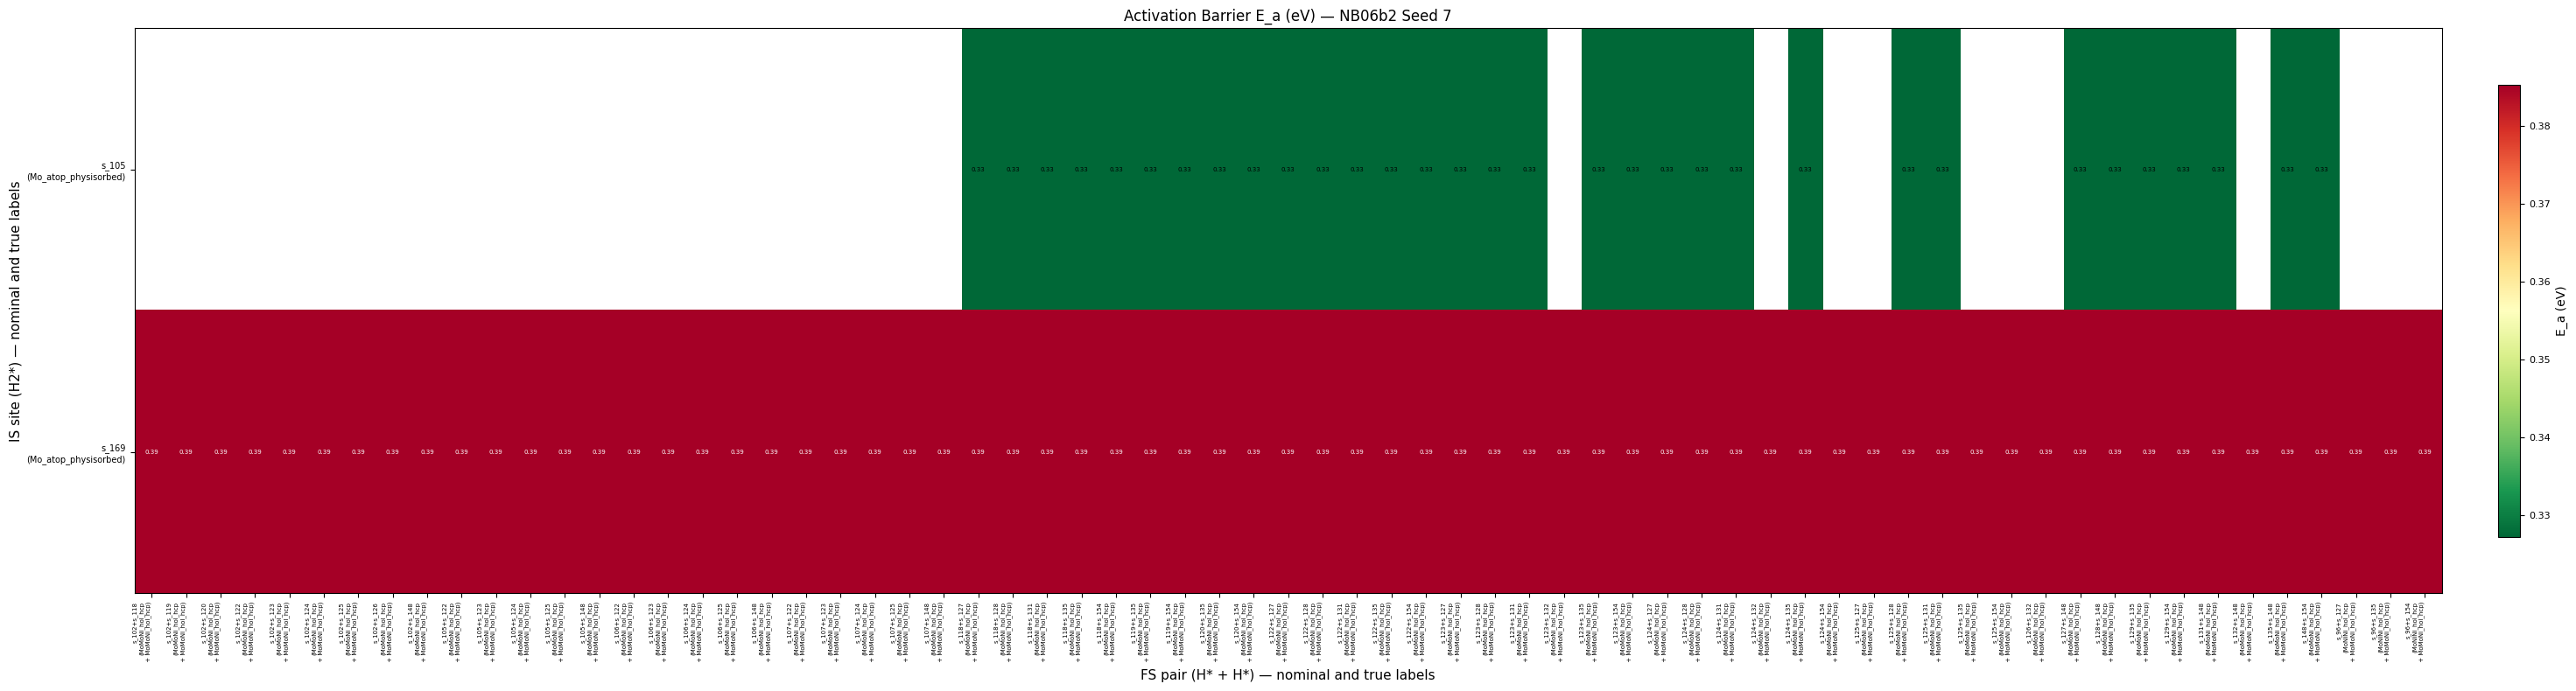

Saved: barrier_heatmap.png


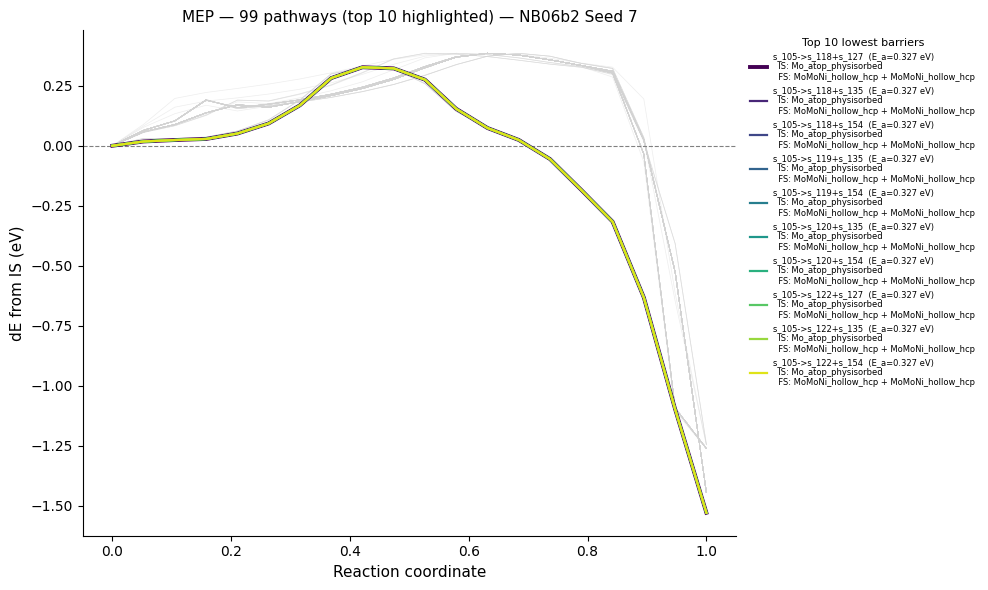

Saved: mep_overlay.png


In [19]:
# ─────────────────────────────────────────────────────────────
# Cell F — Plot barrier heatmap and MEP overlay
# ─────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.cm as cm
import numpy as np

if not results:
    print('No results to plot. Run Cell E first.')
else:
    df_plot = pd.DataFrame(results).dropna(subset=['E_a'])

    # Display labels combining nominal + true
    is_display = {}
    for _, row in df_plot.iterrows():
        is_display[row['is_site']] = f'{row["is_site"]}\n({row.get("is_true_label","?")})'

    fs_display = {}
    for _, row in df_plot.iterrows():
        t1 = (row.get('fs_true_label1', '?') or '?')
        t2 = (row.get('fs_true_label2', '?') or '?')
        for t in [t1, t2]: pass
        t1_s = (t1.replace('_hollow_fcc','_hol_fcc')
                  .replace('_hollow_hcp','_hol_hcp')
                  .replace('_bridge','_br')
                  .replace('_atop','_at')
                  .replace('_physisorbed','_phys'))
        t2_s = (t2.replace('_hollow_fcc','_hol_fcc')
                  .replace('_hollow_hcp','_hol_hcp')
                  .replace('_bridge','_br')
                  .replace('_atop','_at')
                  .replace('_physisorbed','_phys'))
        fs_display[row['fs_pair']] = f'{row["fs_pair"]}\n({t1_s}\n + {t2_s})'

    # ══════════════════════════════════════════════════════════
    # Plot 1: Barrier matrix heatmap
    # ══════════════════════════════════════════════════════════
    is_sites_u = sorted(df_plot['is_site'].unique())
    fs_pairs_u = sorted(df_plot['fs_pair'].unique())

    matrix = np.full((len(is_sites_u), len(fs_pairs_u)), np.nan)
    for _, row in df_plot.iterrows():
        i = is_sites_u.index(row['is_site'])
        j = fs_pairs_u.index(row['fs_pair'])
        matrix[i, j] = row['E_a']

    fig, ax = plt.subplots(figsize=(max(12, len(fs_pairs_u)*0.5),
                                    max(8, len(is_sites_u)*0.5)))
    im = ax.imshow(matrix, cmap='RdYlGn_r', aspect='auto',
                   vmin=np.nanmin(matrix), vmax=np.nanmax(matrix))

    ax.set_xticks(range(len(fs_pairs_u)))
    ax.set_xticklabels([fs_display[p] for p in fs_pairs_u],
                       rotation=90, ha='right', fontsize=5)
    ax.set_yticks(range(len(is_sites_u)))
    ax.set_yticklabels([is_display[s] for s in is_sites_u], fontsize=7)
    ax.set_xlabel('FS pair (H* + H*) — nominal and true labels', fontsize=11)
    ax.set_ylabel('IS site (H2*) — nominal and true labels', fontsize=11)
    ax.set_title(f'Activation Barrier E_a (eV) — NB06b2 Seed {SEED}', fontsize=12)

    # Annotate only if matrix is not too dense
    if len(is_sites_u) * len(fs_pairs_u) < 500:
        for i in range(len(is_sites_u)):
            for j in range(len(fs_pairs_u)):
                if not np.isnan(matrix[i, j]):
                    ax.text(j, i, f'{matrix[i,j]:.2f}',
                            ha='center', va='center', fontsize=5,
                            color='white' if matrix[i,j] > np.nanmean(matrix)
                                          else 'black')

    cbar = fig.colorbar(im, ax=ax, orientation='vertical',
                        pad=0.02, shrink=0.8, aspect=20)
    cbar.set_label('E_a (eV)', fontsize=10)
    cbar.ax.tick_params(labelsize=8)

    plt.tight_layout()
    plt.savefig(f'results/notebook06b2-Neb-dissociation/{SEED}/multi/barrier_heatmap.png',
                dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved: barrier_heatmap.png')

    # ══════════════════════════════════════════════════════════
    # Plot 2: MEP overlay (top 10 highlighted)
    # ══════════════════════════════════════════════════════════
    N_HIGHLIGHT = 10
    df_top   = df_plot.nsmallest(N_HIGHLIGHT, 'E_a').reset_index(drop=True)
    df_other = df_plot[~df_plot['label'].isin(df_top['label'])]

    fig, ax = plt.subplots(figsize=(10, 6))

    for _, row in df_other.iterrows():
        path_f = (f'results/notebook06b2-Neb-dissociation/{SEED}/multi/'
                  f'{row["label"]}/neb_path.dat')
        if not os.path.exists(path_f): continue
        data = np.loadtxt(path_f, comments='#')
        if data.ndim < 2: continue
        ax.plot(data[:, 0], data[:, 2],
                color='lightgray', linewidth=0.5, alpha=0.4, zorder=1)

    colors = cm.viridis(np.linspace(0, 0.95, len(df_top)))
    for (_, row), color in zip(df_top.iterrows(), colors):
        path_f = (f'results/notebook06b2-Neb-dissociation/{SEED}/multi/'
                  f'{row["label"]}/neb_path.dat')
        if not os.path.exists(path_f): continue
        data = np.loadtxt(path_f, comments='#')
        if data.ndim < 2: continue
        x, de = data[:, 0], data[:, 2]
        lw = 2.8 if row['label'] == df_top.iloc[0]['label'] else 1.6
        is_t  = row.get('is_true_label','?')  or '?'
        fs_t1 = row.get('fs_true_label1','?') or '?'
        fs_t2 = row.get('fs_true_label2','?') or '?'
        leg = (f'{row["is_site"]}->{row["fs_pair"]}  '
               f'(E_a={row["E_a"]:.3f} eV)\n'
               f'  IS: {is_t}\n'
               f'  FS: {fs_t1} + {fs_t2}')
        ax.plot(x, de, color=color, linewidth=lw, label=leg, zorder=3)

    ax.axhline(0, color='gray', linewidth=0.8, linestyle='--', zorder=2)
    ax.set_xlabel('Reaction coordinate', fontsize=11)
    ax.set_ylabel('dE from IS (eV)', fontsize=11)
    ax.set_title(f'MEP — {len(df_plot)} pathways (top {N_HIGHLIGHT} highlighted) — NB06b2 Seed {SEED}',
                 fontsize=11)
    ax.spines[['top','right']].set_visible(False)
    ax.legend(fontsize=6, frameon=False, ncol=1,
              bbox_to_anchor=(1.01, 1), loc='upper left',
              title=f'Top {N_HIGHLIGHT} lowest barriers',
              title_fontsize=8)
    plt.tight_layout()
    plt.savefig(f'results/notebook06b2-Neb-dissociation/{SEED}/multi/mep_overlay.png',
                dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved: mep_overlay.png')


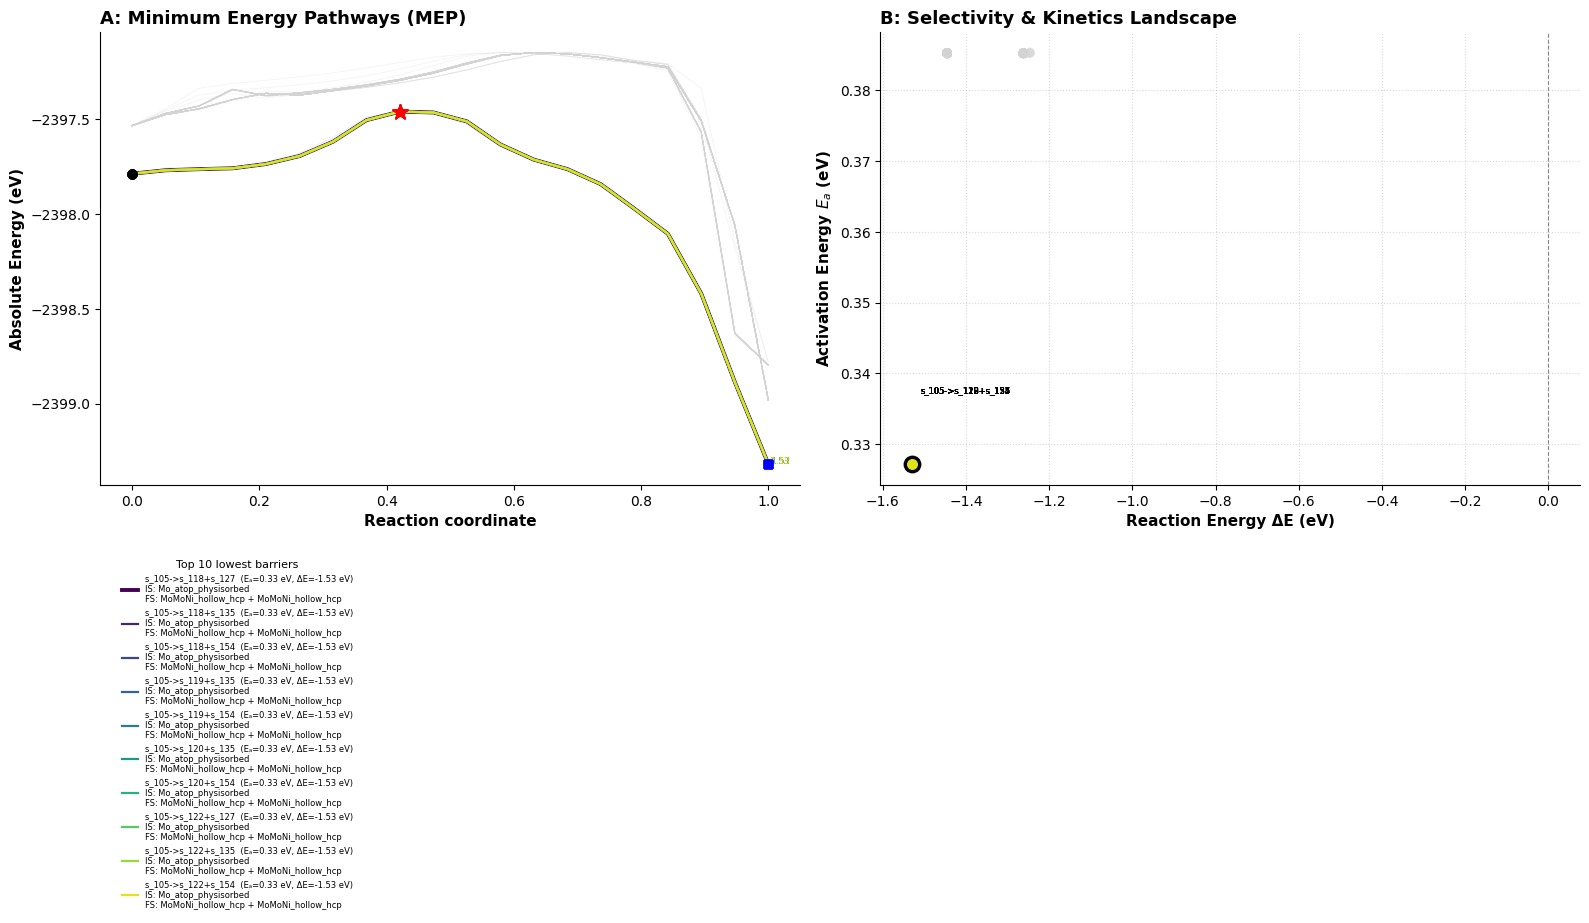

Saved 2-panel layout: results/notebook06b2-Neb-dissociation/7/multi/mep_selectivity_panel.png


In [17]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# ──────────────────────────────────────────────────────────────────────
# 1. Data Setup & Pre-calculations
# ──────────────────────────────────────────────────────────────────────
N_HIGHLIGHT = 10

# Calculate raw dE (FS - IS) for every pathway to use in Panel B
dE_list = []
for idx, row in df_plot.iterrows():
    path_f = f'results/notebook06b2-Neb-dissociation/{SEED}/multi/{row["label"]}/neb_path.dat'
    if os.path.exists(path_f):
        data = np.loadtxt(path_f, comments='#')
        if data.ndim >= 2:
            dE_list.append(data[-1, 1] - data[0, 1])
            continue
    dE_list.append(np.nan)

df_plot['dE_calculated'] = dE_list

# Split into top 10 lowest barriers and the rest
df_top = df_plot.nsmallest(N_HIGHLIGHT, 'E_a').reset_index(drop=True)
df_other = df_plot[~df_plot['label'].isin(df_top['label'])]

# ──────────────────────────────────────────────────────────────────────
# 2. Figure Layout Initialization
# ──────────────────────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))
colors = cm.viridis(np.linspace(0, 0.95, len(df_top)))

# ======================================================================
# PANEL A: MEP Overlay (Absolute Energies)
# ======================================================================

# Background pathways (light gray)
for _, row in df_other.iterrows():
    path_f = f'results/notebook06b2-Neb-dissociation/{SEED}/multi/{row["label"]}/neb_path.dat'
    if not os.path.exists(path_f): continue
    data = np.loadtxt(path_f, comments='#')
    if data.ndim < 2: continue

    ax1.plot(data[:, 0], data[:, 1], color='lightgray', linewidth=0.6, alpha=0.25, zorder=1)

# Highlighted pathways (Top 10)
for (_, row), color in zip(df_top.iterrows(), colors):
    path_f = f'results/notebook06b2-Neb-dissociation/{SEED}/multi/{row["label"]}/neb_path.dat'
    if not os.path.exists(path_f): continue
    data = np.loadtxt(path_f, comments='#')
    if data.ndim < 2: continue

    x, E = data[:, 0], data[:, 1]
    ts_idx = np.argmax(E)
    lw = 2.8 if row['label'] == df_top.iloc[0]['label'] else 1.6

    is_t  = row.get('is_true_label', '?') or '?'
    fs_t1 = row.get('fs_true_label1', '?') or '?'
    fs_t2 = row.get('fs_true_label2', '?') or '?'
    dE = row['dE_calculated']

    leg = (f'{row["is_site"]}->{row["fs_pair"]}  '
           f'(Eₐ={row["E_a"]:.2f} eV, ΔE={dE:+.2f} eV)\n'
           f'IS: {is_t}\n'
           f'FS: {fs_t1} + {fs_t2}')

    # Plot lines & markers
    ax1.plot(x, E, color=color, linewidth=lw, label=leg, zorder=3)
    ax1.scatter(x[0], E[0], marker='o', s=40, color='black', zorder=5)
    ax1.scatter(x[ts_idx], E[ts_idx], marker='*', s=120, color='red', zorder=6)
    ax1.scatter(x[-1], E[-1], marker='s', s=40, color='blue', zorder=5)
    
    ax1.text(x[-1], E[-1], f'{dE:+.2f}', fontsize=6, color=color)

# Styling Panel A
ax1.set_xlabel('Reaction coordinate', fontsize=11, fontweight='bold')
ax1.set_ylabel('Absolute Energy (eV)', fontsize=11, fontweight='bold')
ax1.set_title('A: Minimum Energy Pathways (MEP)', fontsize=13, fontweight='bold', loc='left')
ax1.spines[['top', 'right']].set_visible(False)
ax1.ticklabel_format(useOffset=False, style='plain')

ax1.legend(fontsize=6, frameon=False, ncol=1,
          bbox_to_anchor=(0.02, -0.15),
          loc='upper left',
          title=f'Top {N_HIGHLIGHT} lowest barriers',
          title_fontsize=8)

# ======================================================================
# PANEL B: Selectivity Landscape (Ea vs ΔE)
# ======================================================================

# Plot all background pathways
ax2.scatter(df_other['dE_calculated'], df_other['E_a'],
            color='lightgray', alpha=0.6, s=50, edgecolors='none', 
            label='Other Pathways', zorder=2)

# Plot top pathways matching Panel A colors
for (_, row), color in zip(df_top.iterrows(), colors):
    # Marker is sized slightly larger if it represents the lowest overall barrier
    s_size = 140 if row['label'] == df_top.iloc[0]['label'] else 80
    
    ax2.scatter(row['dE_calculated'], row['E_a'],
                color=color, s=s_size, edgecolors='black', 
                linewidths=1.0, zorder=4)
    
    # Label specific points on the scatter plot for mapping clarity
    ax2.text(row['dE_calculated'] + 0.02, row['E_a'] + 0.01, 
             f'{row["is_site"]}->{row["fs_pair"]}', fontsize=6, color='black', zorder=5)

# Styling Panel B
ax2.set_xlabel('Reaction Energy ΔE (eV)', fontsize=11, fontweight='bold')
ax2.set_ylabel('Activation Energy $E_a$ (eV)', fontsize=11, fontweight='bold')
ax2.set_title('B: Selectivity & Kinetics Landscape', fontsize=13, fontweight='bold', loc='left')
ax2.spines[['top', 'right']].set_visible(False)
ax2.grid(True, linestyle=':', alpha=0.5, zorder=1)

# Quadrant references to make the kinetic vs thermodynamic landscape intuitive
ax2.axvline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.5, zorder=1)

# ──────────────────────────────────────────────────────────────────────
# 3. Save and Render
# ──────────────────────────────────────────────────────────────────────
plt.tight_layout()

# Extra room at bottom to prevent the multi-line Panel A legend from clipping
plt.subplots_adjust(bottom=0.3) 

output_path = f'results/notebook06b2-Neb-dissociation/{SEED}/multi/mep_selectivity_panel.png'
plt.savefig(output_path, dpi=150, bbox_inches='tight')
plt.show()

print(f'Saved 2-panel layout: {output_path}')